# Comparación Visual de Técnicas de Tokenización para Series Temporales

## Objetivo

Comparar las **6 técnicas de tokenización** identificadas en el Anteproyecto-RITMO sobre los datasets **Electricity** y **ETTh2**.

### Técnicas Comparadas

| # | Técnica | Paper Original | Tipo |
|---|---------|---------------|------|
| 1 | **HMM (Viterbi)** | Tesis RITMO | Estados ocultos de Markov |
| 2 | **SAX** | Lin et al. (2007) | Discretización gaussiana |
| 3 | **LLMTime** | Gruver et al. (2023) | Conversión a texto |
| 4 | **PatchTST** | Nie et al. (2023) | Segmentación en patches |
| 5 | **Autoformer** | Wu et al. (2021) | Descomposición trend-seasonal |
| 6 | **MOMENT** | Goswami et al. (2024) | Masked patches pre-training |

### Datasets Utilizados

- **Electricity**: Consumo eléctrico MT_320 (26,304 timesteps, 321 variables)
- **ETTh2**: Electric Transformer Temperature hourly (17,420 timesteps, 7 variables)

Ambos datasets tienen **cache HMM pre-computado** con diferentes valores de K.

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
import sys
from scipy import stats

# Añadir path del proyecto
sys.path.append('/home/jaime/TFG/RITMO')

# Imports de técnicas de tokenización
from tecnicas import (
    sax_discretize, visualize_sax,
    text_based_tokenize, visualize_text_based,
    patching_tokenize, visualize_patches,
    decomposition_tokenize, visualize_decomposition,
    foundation_tokenize, visualize_foundation
)

# Configuración matplotlib para publicación
plt.rcParams['figure.figsize'] = (18, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 15
sns.set_style('whitegrid')
sns.set_palette('husl')

print("[OK] Imports completados")
print(f"Versiones: NumPy {np.__version__}, Pandas {pd.__version__}, Matplotlib {plt.matplotlib.__version__}")

[OK] Imports completados
Versiones: NumPy 2.2.6, Pandas 2.3.3, Matplotlib 3.10.8


In [2]:
# Definir paths
BASE_DIR = Path('/home/jaime/TFG/RITMO')
DATASET_DIR = BASE_DIR / 'dataset'
CACHE_DIR = BASE_DIR / 'cache'

# Cargar cache HMM pre-computado
cache_electricity = pickle.load(open(CACHE_DIR / 'results_electricity.pkl', 'rb'))
cache_etth2 = pickle.load(open(CACHE_DIR / 'results_etth2.pkl', 'rb'))

print("[CACHE HMM]")
print(f"  Electricity: {len(cache_electricity)} configuraciones")
print(f"  ETTh2: {len(cache_etth2)} configuraciones")
print(f"\n[CACHE KEYS] {list(cache_electricity[0].keys())}")

[CACHE HMM]
  Electricity: 42 configuraciones
  ETTh2: 42 configuraciones

[CACHE KEYS] ['K', 'seed', 'data_config', 'train_size', 'revin_success', 'revin_mse', 'hmm_converged', 'hmm_n_iter', 'hmm_checks', 'log_likelihood', 'AIC', 'BIC', 'unique_states', 'n_tokens_llm', 'n_segments', 'compression_ratio', 'avg_segment_duration', 'state_entropy', 'viterbi_checks', 'data_raw', 'data_norm', 'states', 'params']


In [3]:
# Cargar datasets raw (solo para referencia, usaremos datos del cache)
df_electricity = pd.read_csv(DATASET_DIR / 'electricity' / 'electricity.csv')
df_etth2 = pd.read_csv(DATASET_DIR / 'ETT-small' / 'ETTh2.csv')

print("[DATASETS RAW]")
print(f"  Electricity: {df_electricity.shape[0]} timesteps, {df_electricity.shape[1]-1} variables (sin 'date')")
print(f"    - Columnas: {df_electricity.columns.tolist()[:5]} ... (primeras 5)")
print(f"  ETTh2: {df_etth2.shape[0]} timesteps, {df_etth2.shape[1]-1} variables (sin 'date')")
print(f"    - Columnas: {df_etth2.columns.tolist()}")

[DATASETS RAW]
  Electricity: 26304 timesteps, 321 variables (sin 'date')
    - Columnas: ['date', '0', '1', '2', '3'] ... (primeras 5)
  ETTh2: 17420 timesteps, 7 variables (sin 'date')
    - Columnas: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


In [4]:
# Explorar valores de K disponibles
k_values_elec = sorted(set([entry['K'] for entry in cache_electricity]))
k_values_etth2 = sorted(set([entry['K'] for entry in cache_etth2]))

print("[VALORES K DISPONIBLES]")
print(f"  Electricity: {k_values_elec}")
print(f"  ETTh2: {k_values_etth2}")

# Seleccionar K=5
K_SELECTED = 5

# Buscar entrada correspondiente a K=5
hmm_elec = [e for e in cache_electricity if e['K'] == K_SELECTED][0]
hmm_etth2 = [e for e in cache_etth2 if e['K'] == K_SELECTED][0]

print(f"\n[CONFIGURACIÓN SELECCIONADA: K={K_SELECTED}]")
print("\nElectricity:")
print(f"  - Convergencia: {hmm_elec['hmm_converged']}")
print(f"  - Iteraciones EM: {hmm_elec['hmm_n_iter']}")
print(f"  - Log-likelihood: {hmm_elec['log_likelihood']:.2f}")
print(f"  - AIC: {hmm_elec['AIC']:.2f}")
print(f"  - BIC: {hmm_elec['BIC']:.2f}")
print(f"  - Compression Ratio: {hmm_elec['compression_ratio']:.2f}")
print(f"  - Entropía Estados: {hmm_elec['state_entropy']:.3f}")

print("\nETTh2:")
print(f"  - Convergencia: {hmm_etth2['hmm_converged']}")
print(f"  - Iteraciones EM: {hmm_etth2['hmm_n_iter']}")
print(f"  - Log-likelihood: {hmm_etth2['log_likelihood']:.2f}")
print(f"  - AIC: {hmm_etth2['AIC']:.2f}")
print(f"  - BIC: {hmm_etth2['BIC']:.2f}")
print(f"  - Compression Ratio: {hmm_etth2['compression_ratio']:.2f}")
print(f"  - Entropía Estados: {hmm_etth2['state_entropy']:.3f}")

[VALORES K DISPONIBLES]
  Electricity: [3, 4, 5, 6, 7, 8, 9]
  ETTh2: [3, 4, 5, 6, 7, 8, 9]

[CONFIGURACIÓN SELECCIONADA: K=5]

Electricity:
  - Convergencia: True
  - Iteraciones EM: 177
  - Log-likelihood: -10461.81
  - AIC: 20993.61
  - BIC: 21267.34
  - Compression Ratio: 6.45
  - Entropía Estados: 1.583

ETTh2:
  - Convergencia: True
  - Iteraciones EM: 53
  - Log-likelihood: -1833.09
  - AIC: 3736.19
  - BIC: 3983.43
  - Compression Ratio: 16.43
  - Entropía Estados: 1.603


In [5]:
# Extraer series normalizadas y estados del cache
# ELECTRICITY
elec_data_norm = hmm_elec['data_norm']  # Serie normalizada con RevIN
elec_states = hmm_elec['states']  # Estados Viterbi (secuencia óptima)
elec_params = hmm_elec['params']  # Parámetros HMM: {A, pi, mu, sigma}

# ETTh2
etth2_data_norm = hmm_etth2['data_norm']
etth2_states = hmm_etth2['states']
etth2_params = hmm_etth2['params']

print("[DATOS EXTRAÍDOS DEL CACHE]")
print(f"\nElectricity:")
print(f"  - Serie normalizada: {len(elec_data_norm)} timesteps")
print(f"  - Estados Viterbi: {len(elec_states)} tokens")
print(f"  - Estados únicos usados: {len(np.unique(elec_states))} / {K_SELECTED}")
print(f"  - Parámetros HMM:")
print(f"      mu (medias): {elec_params['mu']}")
print(f"      sigma (std): {elec_params['sigma']}")

print(f"\nETTh2:")
print(f"  - Serie normalizada: {len(etth2_data_norm)} timesteps")
print(f"  - Estados Viterbi: {len(etth2_states)} tokens")
print(f"  - Estados únicos usados: {len(np.unique(etth2_states))} / {K_SELECTED}")
print(f"  - Parámetros HMM:")
print(f"      mu (medias): {etth2_params['mu']}")
print(f"      sigma (std): {etth2_params['sigma']}")

[DATOS EXTRAÍDOS DEL CACHE]

Electricity:
  - Serie normalizada: 18412 timesteps
  - Estados Viterbi: 18412 tokens
  - Estados únicos usados: 5 / 5
  - Parámetros HMM:
      mu (medias): [-0.72981995  0.51625283 -0.1039296  -1.28926035  1.70443694]
      sigma (std): [0.19365815 0.25434948 0.22212615 0.21680156 0.76668403]

ETTh2:
  - Serie normalizada: 8640 timesteps
  - Estados Viterbi: 8640 tokens
  - Estados únicos usados: 5 / 5
  - Parámetros HMM:
      mu (medias): [-0.13346396  1.42356159 -1.38693213  0.53497013 -0.82461555]
      sigma (std): [0.20121107 0.38832149 0.22157581 0.22249028 0.18249821]


In [6]:
N_TIMESTEPS = 1500

# Electricity
elec_series = elec_data_norm[:N_TIMESTEPS]
elec_states_vis = elec_states[:N_TIMESTEPS]

# ETTh2
etth2_series = etth2_data_norm[:N_TIMESTEPS]
etth2_states_vis = etth2_states[:N_TIMESTEPS]

print(f"[VENTANA DE VISUALIZACIÓN]")
print(f"  Timesteps seleccionados: {N_TIMESTEPS}")
print(f"  Porcentaje de serie completa:")
print(f"    - Electricity: {N_TIMESTEPS/len(elec_data_norm)*100:.1f}%")
print(f"    - ETTh2: {N_TIMESTEPS/len(etth2_data_norm)*100:.1f}%")

[VENTANA DE VISUALIZACIÓN]
  Timesteps seleccionados: 1500
  Porcentaje de serie completa:
    - Electricity: 8.1%
    - ETTh2: 17.4%


In [7]:
print("[TOKENIZANDO ELECTRICITY]")

# SAX - Discretización con alfabeto de 8 símbolos
elec_sax = sax_discretize(elec_series, alphabet_size=8)
print(f"  SAX: {elec_sax['vocabulary_size']} símbolos, {elec_sax['num_tokens']} tokens")

# LLMTime - Conversión a texto base-10 con 2 decimales
elec_text = text_based_tokenize(elec_series, base=10, precision=2)
print(f"  LLMTime: {elec_text['num_tokens']} caracteres, vocabulario={elec_text['vocabulary_size']}")

# PatchTST - Segmentación en patches de 16 timesteps sin solapamiento
elec_patch_array = patching_tokenize(elec_series, patch_len=16, stride=16)
elec_patch = visualize_patches(elec_series, elec_patch_array, 16, 16)
print(f"  PatchTST: {elec_patch['num_patches']} patches, CR={elec_patch['compression_ratio']:.2f}")

# Autoformer - Descomposición trend-seasonal con ventana móvil=25
elec_decomp = decomposition_tokenize(elec_series, kernel_size=25)
print(f"  Autoformer: {elec_decomp['num_tokens']} componentes (trend + seasonal)")

# MOMENT - Masked patches con 30% enmascarado
elec_foundation = foundation_tokenize(elec_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
print(f"  MOMENT: {elec_foundation['num_patches']} patches, {elec_foundation['num_masked']} masked ({elec_foundation['mask_ratio_actual']*100:.1f}%)")

print("\n[TOKENIZANDO ETTh2]")

etth2_sax = sax_discretize(etth2_series, alphabet_size=8)
print(f"  SAX: {etth2_sax['vocabulary_size']} símbolos, {etth2_sax['num_tokens']} tokens")

etth2_text = text_based_tokenize(etth2_series, base=10, precision=2)
print(f"  LLMTime: {etth2_text['num_tokens']} caracteres, vocabulario={etth2_text['vocabulary_size']}")

etth2_patch_array = patching_tokenize(etth2_series, patch_len=16, stride=16)
etth2_patch = visualize_patches(etth2_series, etth2_patch_array, 16, 16)
print(f"  PatchTST: {etth2_patch['num_patches']} patches, CR={etth2_patch['compression_ratio']:.2f}")

etth2_decomp = decomposition_tokenize(etth2_series, kernel_size=25)
print(f"  Autoformer: {etth2_decomp['num_tokens']} componentes (trend + seasonal)")

etth2_foundation = foundation_tokenize(etth2_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
print(f"  MOMENT: {etth2_foundation['num_patches']} patches, {etth2_foundation['num_masked']} masked ({etth2_foundation['mask_ratio_actual']*100:.1f}%)")

print("\n[OK] Todas las técnicas aplicadas")

[TOKENIZANDO ELECTRICITY]
  SAX: 8 símbolos, 1500 tokens
  LLMTime: 15826 caracteres, vocabulario=13
  PatchTST: 93 patches, CR=16.13
  Autoformer: 2 componentes (trend + seasonal)
  MOMENT: 93 patches, 28 masked (30.1%)

[TOKENIZANDO ETTh2]
  SAX: 8 símbolos, 1500 tokens
  LLMTime: 15024 caracteres, vocabulario=13
  PatchTST: 93 patches, CR=16.13
  Autoformer: 2 componentes (trend + seasonal)
  MOMENT: 93 patches, 28 masked (30.1%)

[OK] Todas las técnicas aplicadas


In [8]:
def create_comparison_table(dataset_name, series_len, hmm_result, hmm_states_vis, sax, text, patch, decomp, foundation):
    """Crear tabla comparativa de métricas de tokenización."""
    # Para HMM: Vocabulary Size = K (5 estados únicos)
    # Num Tokens = número de segmentos en la ventana visible
    # Compression Ratio = serie_len / num_segmentos
    num_segments_vis = np.sum(np.diff(np.concatenate([[hmm_states_vis[0]], hmm_states_vis])) != 0)
    cr_vis = series_len / num_segments_vis if num_segments_vis > 0 else series_len

    data = [
        {
            'Técnica': 'HMM (Viterbi)',
            'Num Tokens (Segmentos)': num_segments_vis,  # CORREGIDO: número de segmentos
            'Compression Ratio': cr_vis,  # CORREGIDO: CR sobre ventana visible
            'Vocabulary Size': hmm_result['K'],  # K=5 estados
            'Tipo': 'Probabilístico',
            'Paper': 'Tesis RITMO (2025)'
        },
        {
            'Técnica': 'SAX',
            'Num Tokens (Segmentos)': sax['num_tokens'],
            'Compression Ratio': sax['compression_ratio'],
            'Vocabulary Size': sax['vocabulary_size'],
            'Tipo': 'Discreto',
            'Paper': 'Lin et al. (2007)'
        },
        {
            'Técnica': 'LLMTime',
            'Num Tokens (Segmentos)': text['num_tokens'],
            'Compression Ratio': text['compression_ratio'],
            'Vocabulary Size': text['vocabulary_size'],
            'Tipo': 'Textual',
            'Paper': 'Gruver et al. (2023)'
        },
        {
            'Técnica': 'PatchTST',
            'Num Tokens (Segmentos)': patch['num_patches'],
            'Compression Ratio': patch['compression_ratio'],
            'Vocabulary Size': 'Continuo',
            'Tipo': 'Segmentación',
            'Paper': 'Nie et al. (2023)'
        },
        {
            'Técnica': 'Autoformer',
            'Num Tokens (Segmentos)': decomp['num_tokens'],
            'Compression Ratio': decomp['compression_ratio'],
            'Vocabulary Size': '2 componentes',
            'Tipo': 'Descomposición',
            'Paper': 'Wu et al. (2021)'
        },
        {
            'Técnica': 'MOMENT',
            'Num Tokens (Segmentos)': foundation['num_patches'],
            'Compression Ratio': foundation['compression_ratio'],
            'Vocabulary Size': f"{foundation['num_masked']} masked",
            'Tipo': 'Pre-training',
            'Paper': 'Goswami et al. (2024)'
        }
    ]
    
    df = pd.DataFrame(data)
    df['Dataset'] = dataset_name
    df['Serie Length'] = series_len
    return df

# Crear tablas - PASAR elec_states_vis y etth2_states_vis
table_elec = create_comparison_table('Electricity', len(elec_series), hmm_elec, elec_states_vis,
                                      elec_sax, elec_text, elec_patch, elec_decomp, elec_foundation)
table_etth2 = create_comparison_table('ETTh2', len(etth2_series), hmm_etth2, etth2_states_vis,
                                       etth2_sax, etth2_text, etth2_patch, etth2_decomp, etth2_foundation)

# Combinar
table_combined = pd.concat([table_elec, table_etth2], ignore_index=True)

print("="*120)
print("TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN")
print("="*120)
print(table_combined.to_string(index=False))
print("="*120)

TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN
      Técnica  Num Tokens (Segmentos)  Compression Ratio Vocabulary Size           Tipo                 Paper     Dataset  Serie Length
HMM (Viterbi)                     223           6.726457               5 Probabilístico    Tesis RITMO (2025) Electricity          1500
          SAX                    1500           1.000000               8       Discreto     Lin et al. (2007) Electricity          1500
      LLMTime                   15826           0.094781              13        Textual  Gruver et al. (2023) Electricity          1500
     PatchTST                      93          16.129032        Continuo   Segmentación     Nie et al. (2023) Electricity          1500
   Autoformer                       2         750.000000   2 componentes Descomposición      Wu et al. (2021) Electricity          1500
       MOMENT                      93          16.129032       28 masked   Pre-training Goswami et al. (2024) Electricity          1500
HM

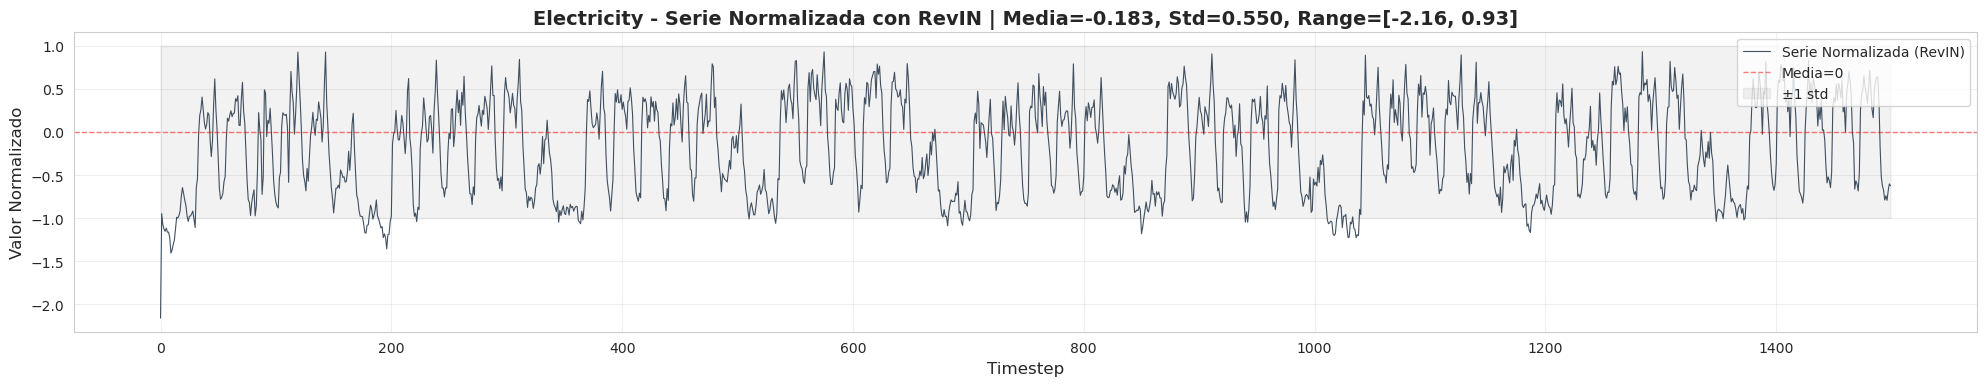

[ESTADÍSTICAS SERIE NORMALIZADA]
  Media: -0.183307 (debe estar cerca de 0)
  Desviación estándar: 0.549546 (debe estar cerca de 1)
  Min: -2.163, Max: 0.934
  Rango: 3.097


In [9]:
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(elec_series, linewidth=0.8, color='#2C3E50', alpha=0.9, label='Serie Normalizada (RevIN)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Media=0')
ax.fill_between(range(len(elec_series)), -1, 1, alpha=0.1, color='gray', label='±1 std')

# Estadísticas
mean_val = elec_series.mean()
std_val = elec_series.std()
min_val = elec_series.min()
max_val = elec_series.max()

ax.set_title(f'Electricity - Serie Normalizada con RevIN | Media={mean_val:.3f}, Std={std_val:.3f}, Range=[{min_val:.2f}, {max_val:.2f}]', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Valor Normalizado', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[ESTADÍSTICAS SERIE NORMALIZADA]")
print(f"  Media: {mean_val:.6f} (debe estar cerca de 0)")
print(f"  Desviación estándar: {std_val:.6f} (debe estar cerca de 1)")
print(f"  Min: {min_val:.3f}, Max: {max_val:.3f}")
print(f"  Rango: {max_val - min_val:.3f}")

## HMM - Estados Ocultos de Markov

**Técnica**: Hidden Markov Model tokenization (propuesta de tesis)

**Descripción**: 
- Entrena HMM con K=5 estados usando algoritmo Baum-Welch (EM)
- Cada estado k tiene distribución gaussiana N(μ_k, σ_k²)
- Algoritmo Viterbi encuentra secuencia óptima de estados Q*
- Estados capturan "regímenes" o "modos" temporales de la serie

**Interpretación**:
- Colores indican estado activo en cada timestep
- Líneas punteadas horizontales muestran medias μ_k de cada estado
- Cambios de color = transiciones entre regímenes

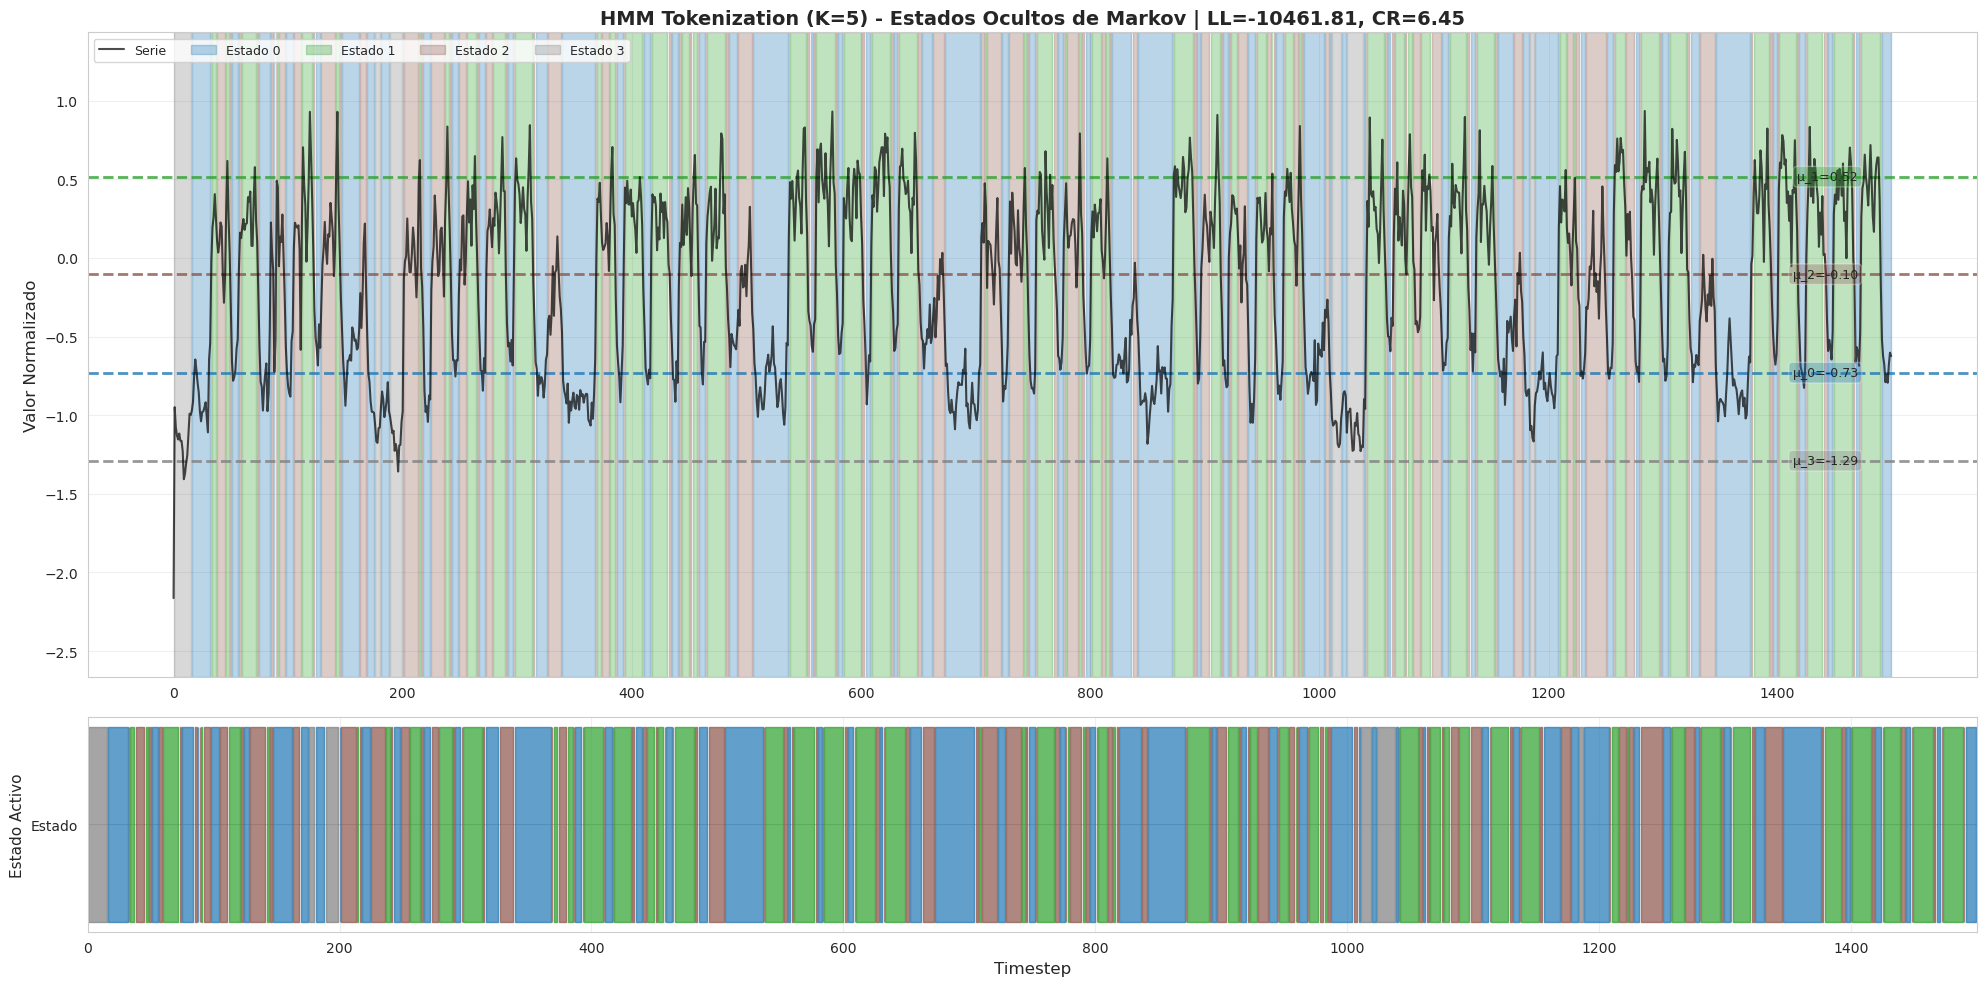

[ESTADÍSTICAS HMM]
  Número de estados (K): 5
  Estados únicos usados: 4
  Compression Ratio: 6.45
  Número de segmentos: 2854
  Duración promedio segmento: 6.45 timesteps
  Entropía estados: 1.583 (max=1.609)

  Parámetros por estado:
    Estado 0: μ=-0.730, σ=0.194, freq=34.9% (524 timesteps)
    Estado 1: μ=0.516, σ=0.254, freq=33.9% (508 timesteps)
    Estado 2: μ=-0.104, σ=0.222, freq=27.2% (408 timesteps)
    Estado 3: μ=-1.289, σ=0.217, freq=4.0% (60 timesteps)
    Estado 4: μ=1.704, σ=0.767, freq=0.0% (0 timesteps)


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'height_ratios': [3, 1]})

# Panel superior: Serie con estados coloreados
ax1.plot(elec_series, linewidth=1.5, color='black', alpha=0.7, label='Serie', zorder=3)

# Colorear regiones por estado
colors = plt.cm.tab10(np.linspace(0, 1, K_SELECTED))
for k in range(K_SELECTED):
    mask = elec_states_vis == k
    if mask.any():
        ax1.fill_between(range(len(elec_series)), elec_series.min()-0.5, elec_series.max()+0.5, 
                         where=mask, color=colors[k], alpha=0.3, label=f'Estado {k}')
        # Línea de media del estado
        mu_k = elec_params['mu'][k]
        sigma_k = elec_params['sigma'][k]
        ax1.axhline(mu_k, color=colors[k], linestyle='--', linewidth=2, alpha=0.8)
        ax1.text(len(elec_series)*0.98, mu_k, f'μ_{k}={mu_k:.2f}', 
                ha='right', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor=colors[k], alpha=0.3))

ax1.set_title(f'HMM Tokenization (K={K_SELECTED}) - Estados Ocultos de Markov | LL={hmm_elec["log_likelihood"]:.2f}, CR={hmm_elec["compression_ratio"]:.2f}', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=12)
ax1.legend(loc='upper left', ncol=K_SELECTED+1, fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(elec_series.min()-0.5, elec_series.max()+0.5)

# Panel inferior: Secuencia de estados
for k in range(K_SELECTED):
    mask = elec_states_vis == k
    ax2.fill_between(range(len(elec_series)), 0, 1, where=mask, color=colors[k], alpha=0.7)

ax2.set_xlabel('Timestep', fontsize=12)
ax2.set_ylabel('Estado Activo', fontsize=11)
ax2.set_yticks([0.5])
ax2.set_yticklabels(['Estado'], fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0, len(elec_series))

plt.tight_layout()
plt.show()

# Estadísticas de estados
print("[ESTADÍSTICAS HMM]")
print(f"  Número de estados (K): {K_SELECTED}")
print(f"  Estados únicos usados: {len(np.unique(elec_states_vis))}")
print(f"  Compression Ratio: {hmm_elec['compression_ratio']:.2f}")
print(f"  Número de segmentos: {hmm_elec['n_segments']}")
print(f"  Duración promedio segmento: {hmm_elec['avg_segment_duration']:.2f} timesteps")
print(f"  Entropía estados: {hmm_elec['state_entropy']:.3f} (max={np.log(K_SELECTED):.3f})")
print(f"\n  Parámetros por estado:")
for k in range(K_SELECTED):
    count = (elec_states_vis == k).sum()
    pct = count / len(elec_states_vis) * 100
    print(f"    Estado {k}: μ={elec_params['mu'][k]:.3f}, σ={elec_params['sigma'][k]:.3f}, freq={pct:.1f}% ({count} timesteps)")

## Discretización basada en breakpoints gaussianos (Lin et al., 2007) SAX

**Descripción**:
- Normaliza serie con z-score
- Divide espacio en N regiones equiprobables bajo N(0,1)
- Asigna símbolo alfabético a cada timestep según región
- Vocabulario de 8 símbolos: {a, b, c, d, e, f, g, h}

**Interpretación**:
- Líneas rojas horizontales = breakpoints gaussianos
- Cada punto coloreado = símbolo discreto asignado
- Reduce serie continua a secuencia de caracteres

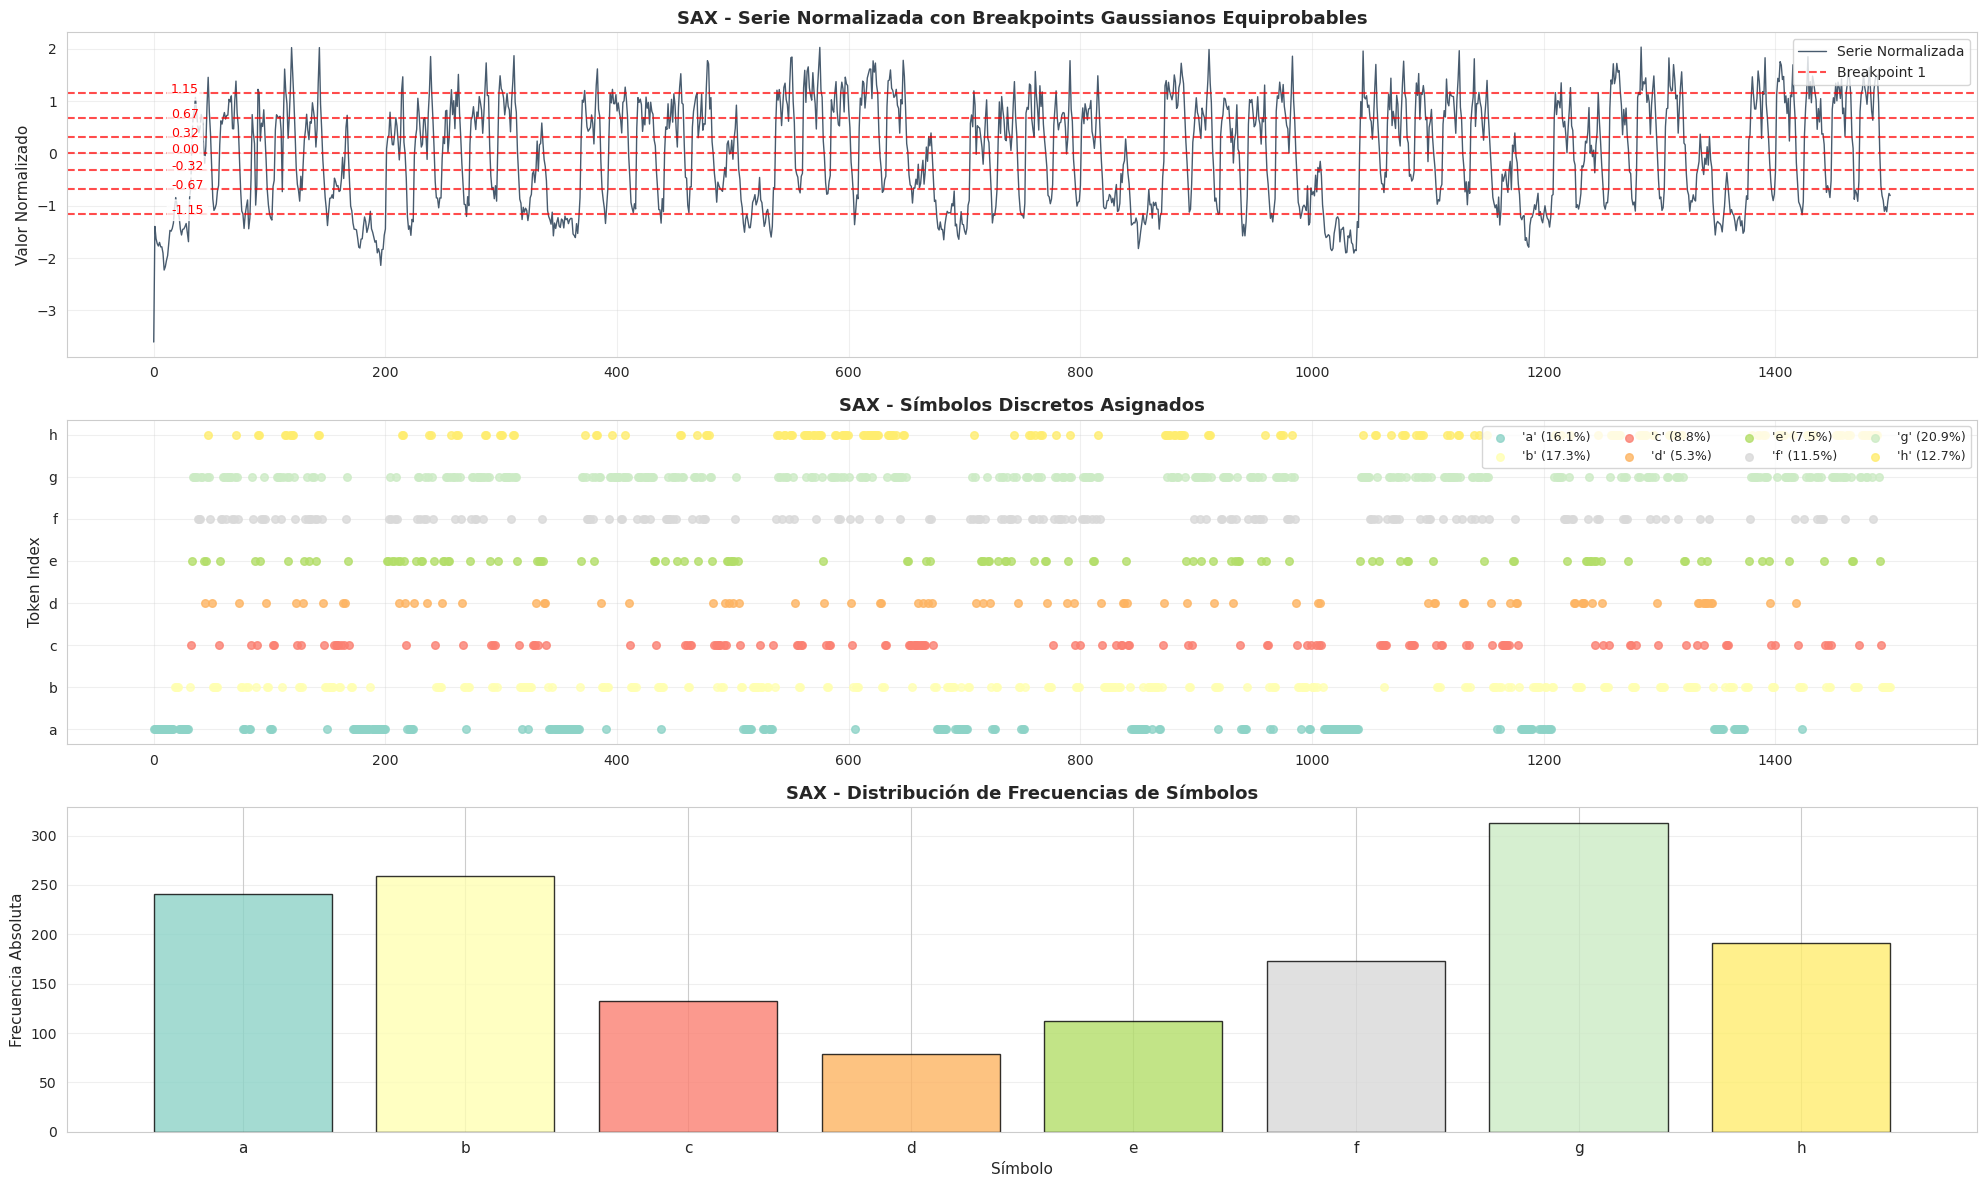

[ESTADÍSTICAS SAX]
  Vocabulary Size: 8
  Símbolos únicos usados: 8
  Num Tokens: 1500
  Compression Ratio: 1.0000 (sin compresión)

  Distribución de símbolos:
    'a': 241 (16.07%)
    'b': 259 (17.27%)
    'c': 132 (8.80%)
    'd': 79 (5.27%)
    'e': 112 (7.47%)
    'f': 173 (11.53%)
    'g': 313 (20.87%)
    'h': 191 (12.73%)


In [11]:
sax_viz = visualize_sax(elec_series, elec_sax['symbols'], elec_sax['tokens'], elec_sax['breakpoints'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 12))

# Panel 1: Serie normalizada con breakpoints
ax1.plot(sax_viz['normalized'], linewidth=1, color='#34495E', alpha=0.9, label='Serie Normalizada')
for i, bp in enumerate(elec_sax['breakpoints']):
    ax1.axhline(bp, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
                label=f'Breakpoint {i+1}' if i == 0 else '')
    ax1.text(len(elec_series)*0.01, bp, f'{bp:.2f}', fontsize=9, color='red', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_title('SAX - Serie Normalizada con Breakpoints Gaussianos Equiprobables', fontsize=13, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel 2: Símbolos discretos (scatter)
colors_sax = plt.cm.Set3(np.linspace(0, 1, elec_sax['vocabulary_size']))
for sym_idx in range(elec_sax['vocabulary_size']):
    mask = elec_sax['tokens'] == sym_idx
    if mask.any():
        count = mask.sum()
        pct = count / len(elec_series) * 100
        ax2.scatter(np.where(mask)[0], elec_sax['tokens'][mask], 
                   color=colors_sax[sym_idx], s=30, alpha=0.8, 
                   label=f"'{elec_sax['alphabet'][sym_idx]}' ({pct:.1f}%)")

ax2.set_title('SAX - Símbolos Discretos Asignados', fontsize=13, fontweight='bold')
ax2.set_ylabel('Token Index', fontsize=11)
ax2.set_yticks(range(elec_sax['vocabulary_size']))
ax2.set_yticklabels([elec_sax['alphabet'][i] for i in range(elec_sax['vocabulary_size'])])
ax2.legend(loc='upper right', ncol=4, fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: Histograma de frecuencias
unique, counts = np.unique(elec_sax['symbols'], return_counts=True)
ax3.bar(range(len(unique)), counts, color=[colors_sax[elec_sax['alphabet'].index(s)] for s in unique], 
        alpha=0.8, edgecolor='black', linewidth=1)
ax3.set_xlabel('Símbolo', fontsize=11)
ax3.set_ylabel('Frecuencia Absoluta', fontsize=11)
ax3.set_title('SAX - Distribución de Frecuencias de Símbolos', fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(unique)))
ax3.set_xticklabels(unique, fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS SAX]")
print(f"  Vocabulary Size: {elec_sax['vocabulary_size']}")
print(f"  Símbolos únicos usados: {len(np.unique(elec_sax['symbols']))}")
print(f"  Num Tokens: {elec_sax['num_tokens']}")
print(f"  Compression Ratio: {elec_sax['compression_ratio']:.4f} (sin compresión)")
print(f"\n  Distribución de símbolos:")
for sym, count in zip(unique, counts):
    pct = count / len(elec_series) * 100
    print(f"    '{sym}': {count} ({pct:.2f}%)")

## LLMTime - Text-based Tokenization

**Técnica**: Serialización a strings numéricos (Gruver et al., 2023)

**Descripción**:
- Convierte cada valor numérico a representación textual
- Base 10 decimal con 2 dígitos de precisión
- Separa dígitos con espacios: 23.45 → " 2 3 . 4 5"
- LLMs procesan serie como secuencia de caracteres

**Interpretación**:
- Longitud de token varía según magnitud del valor
- Valores grandes → tokens más largos
- Compression ratio < 1 (expansión, no compresión)

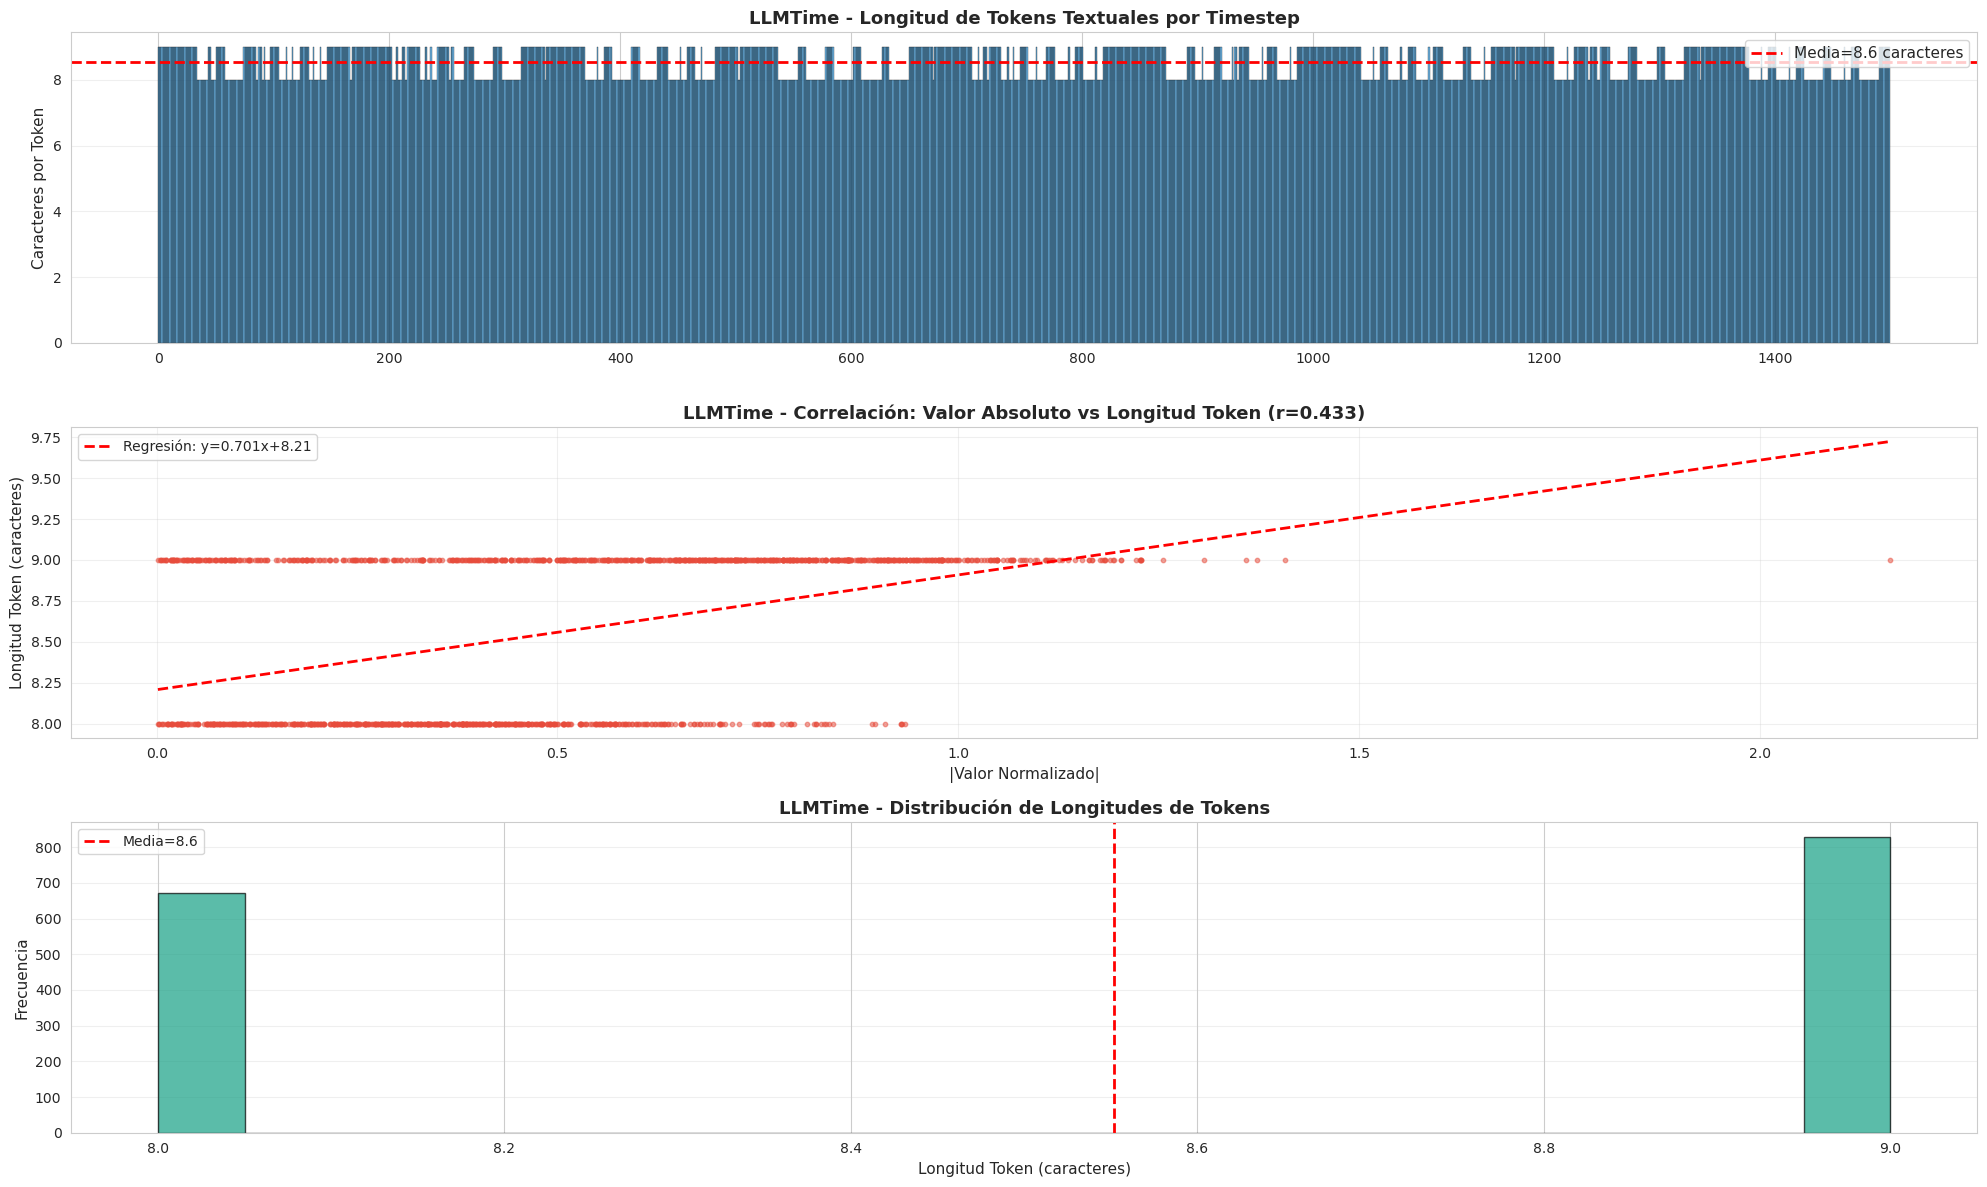

[ESTADÍSTICAS LLMTIME]
  Total caracteres: 12828
  Avg longitud token: 8.55 caracteres
  Compression Ratio: 0.094781 (expansión, no compresión)
  Vocabulary Size: 13 (dígitos 0-9 + signo + punto + separador)

  Ejemplos de serialización (primeros 10 timesteps):
    t=  0: valor= -2.163 → '- 2 . 1 6'
    t=  1: valor= -0.949 → '- 0 . 9 5'
    t=  2: valor= -1.077 → '- 1 . 0 8'
    t=  3: valor= -1.129 → '- 1 . 1 2'
    t=  4: valor= -1.155 → '- 1 . 1 4'
    t=  5: valor= -1.117 → '- 1 . 1 2'
    t=  6: valor= -1.164 → '- 1 . 1 5'
    t=  7: valor= -1.164 → '- 1 . 1 5'
    t=  8: valor= -1.229 → '- 1 . 2 3'
    t=  9: valor= -1.407 → '- 1 . 4 0'


In [12]:
text_viz = visualize_text_based(elec_series, elec_text['tokens_per_value'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 12))

# Panel 1: Longitud de tokens por timestep
ax1.bar(range(len(text_viz['token_lengths'])), text_viz['token_lengths'], 
       color='#3498DB', alpha=0.7, edgecolor='black', linewidth=0.3, width=1)
ax1.axhline(text_viz['avg_token_length'], color='red', linestyle='--', 
           linewidth=2, label=f"Media={text_viz['avg_token_length']:.1f} caracteres")

ax1.set_title('LLMTime - Longitud de Tokens Textuales por Timestep', fontsize=13, fontweight='bold')
ax1.set_ylabel('Caracteres por Token', fontsize=11)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Correlación longitud token vs valor absoluto
abs_values = np.abs(elec_series)
ax2.scatter(abs_values, text_viz['token_lengths'], alpha=0.5, s=10, color='#E74C3C')
# Regresión lineal
z = np.polyfit(abs_values, text_viz['token_lengths'], 1)
p = np.poly1d(z)
x_line = np.linspace(abs_values.min(), abs_values.max(), 100)
ax2.plot(x_line, p(x_line), "r--", linewidth=2, label=f'Regresión: y={z[0]:.3f}x+{z[1]:.2f}')

corr = np.corrcoef(abs_values, text_viz['token_lengths'])[0, 1]
ax2.set_title(f'LLMTime - Correlación: Valor Absoluto vs Longitud Token (r={corr:.3f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('|Valor Normalizado|', fontsize=11)
ax2.set_ylabel('Longitud Token (caracteres)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Panel 3: Histograma de longitudes
ax3.hist(text_viz['token_lengths'], bins=20, color='#16A085', alpha=0.7, edgecolor='black')
ax3.axvline(text_viz['avg_token_length'], color='red', linestyle='--', linewidth=2, 
           label=f"Media={text_viz['avg_token_length']:.1f}")
ax3.set_xlabel('Longitud Token (caracteres)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.set_title('LLMTime - Distribución de Longitudes de Tokens', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Ejemplos de texto generado
print("[ESTADÍSTICAS LLMTIME]")
print(f"  Total caracteres: {text_viz['total_characters']}")
print(f"  Avg longitud token: {text_viz['avg_token_length']:.2f} caracteres")
print(f"  Compression Ratio: {elec_text['compression_ratio']:.6f} (expansión, no compresión)")
print(f"  Vocabulary Size: {elec_text['vocabulary_size']} (dígitos 0-9 + signo + punto + separador)")
print(f"\n  Ejemplos de serialización (primeros 10 timesteps):")
for i in range(min(10, len(elec_text['tokens_per_value']))):
    print(f"    t={i:3d}: valor={elec_series[i]:+7.3f} → '{elec_text['tokens_per_value'][i]}'")

## PatchTST - Patch-based Tokenization

**Técnica**: Segmentación en ventanas fijas (Nie et al., 2023)

**Descripción**:
- Divide serie en patches de longitud fija (16 timesteps)
- Sin solapamiento (stride=16)
- Cada patch es un "token" multidimensional
- Reduce complejidad de O(L²) a O((L/P)²) en Transformers

**Interpretación**:
- Líneas rojas verticales = boundaries entre patches
- Heatmap: cada columna es un patch, colores = valores
- Compression ratio: cuánto se reduce la secuencia

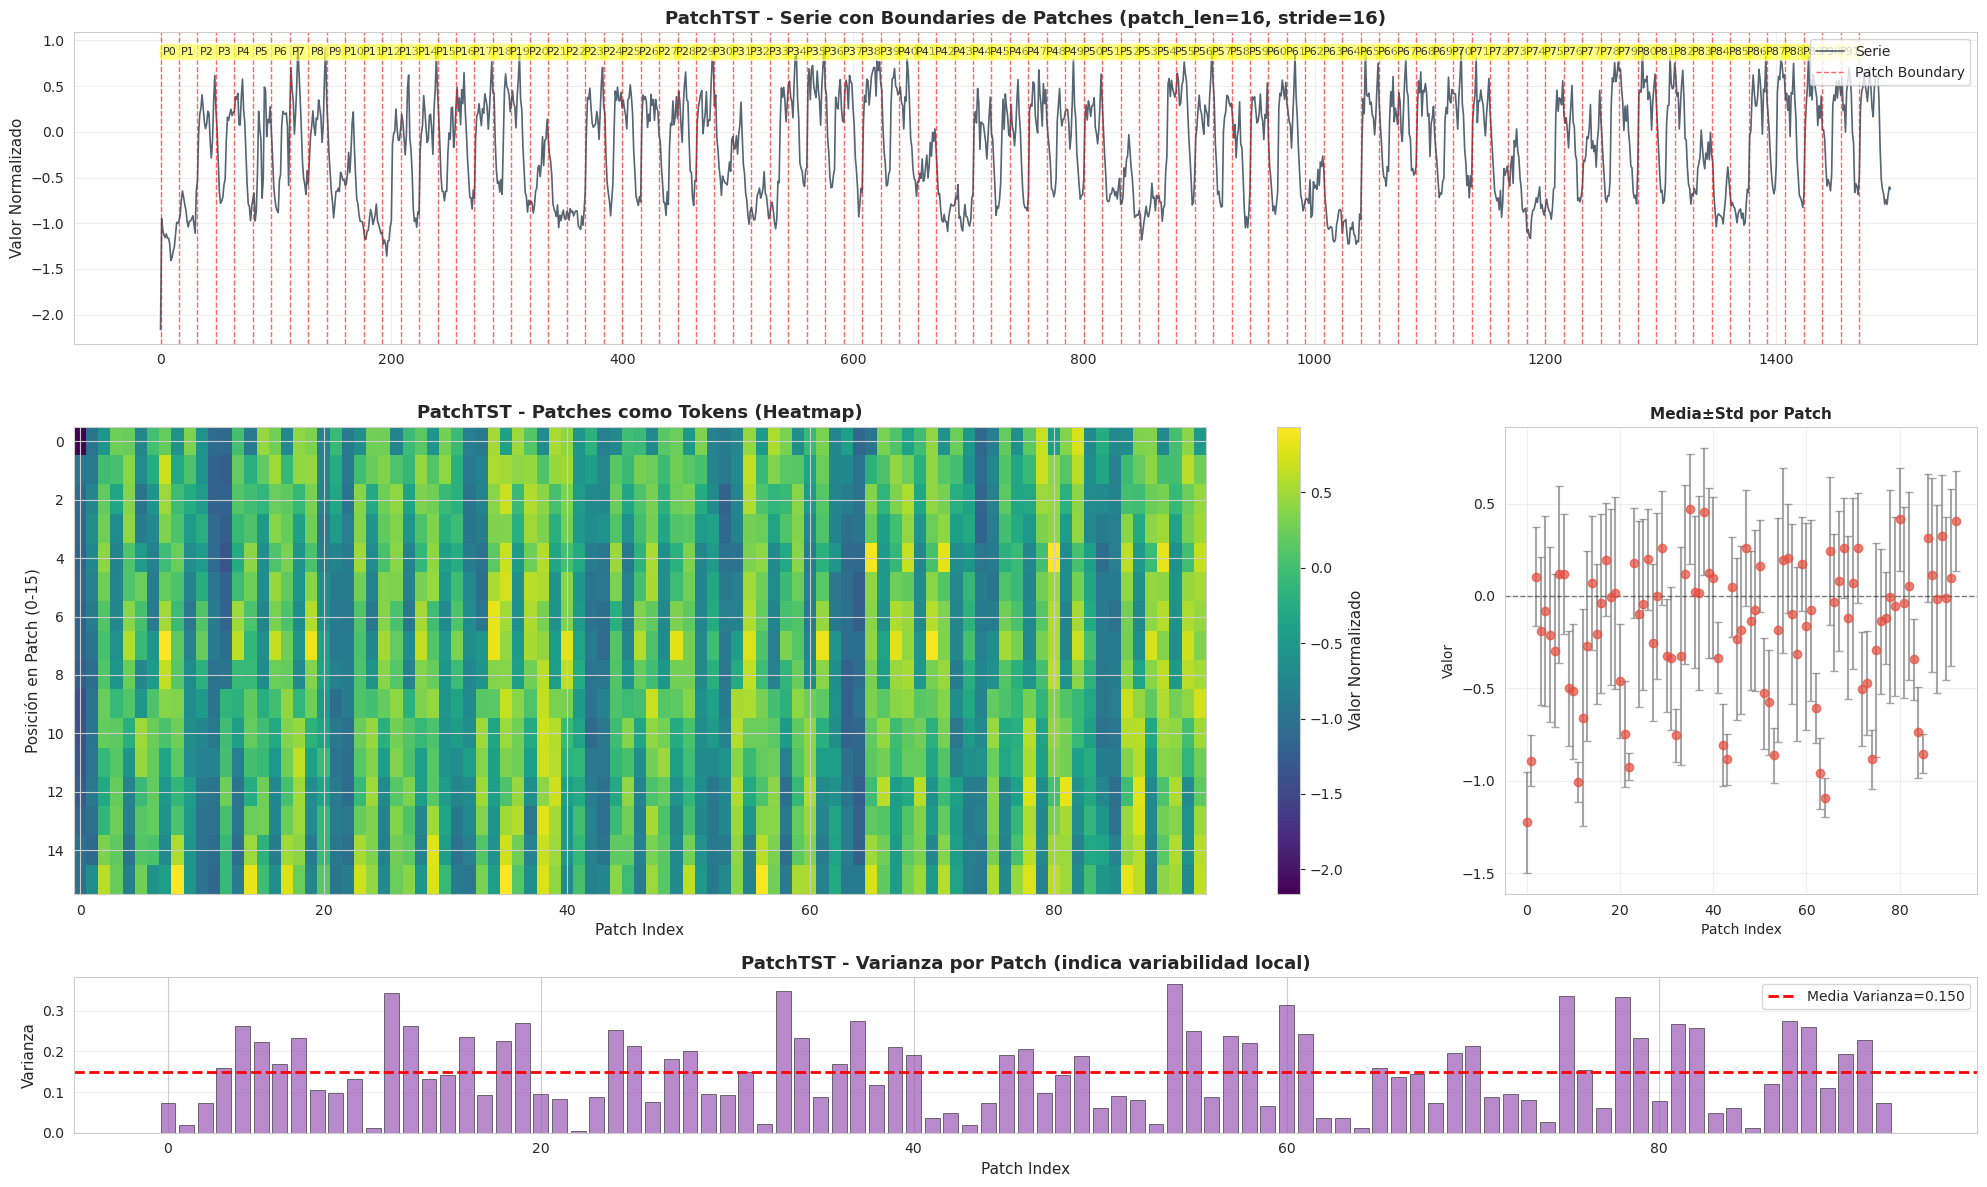

[ESTADÍSTICAS PATCHTST]
  Patch Length: 16 timesteps
  Stride: 16 (sin solapamiento)
  Num Patches: 93
  Compression Ratio: 16.13
  Timesteps cubiertos: 1488
  Timesteps descartados: 12

  Estadísticas de patches:
    Media de varianzas: 0.1495
    Std de varianzas: 0.0925
    Patch más variable: índice 54 (var=0.3650)
    Patch menos variable: índice 22 (var=0.0054)


In [13]:
patch_viz = visualize_patches(elec_series, elec_patch_array, 16, 16)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 3, 1], width_ratios=[3, 1])

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, :])

# Panel 1: Serie con boundaries
ax1.plot(elec_series, linewidth=1.2, color='#2C3E50', alpha=0.8, label='Serie')
for i, pos in enumerate(patch_viz['positions']):
    ax1.axvline(pos, color='red', linestyle='--', linewidth=1, alpha=0.6, 
                label='Patch Boundary' if i == 0 else '')
    if i < len(patch_viz['positions']) - 1:
        mid_pos = pos + 8
        ax1.text(mid_pos, elec_series.max()*0.9, f'P{i}', ha='center', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax1.set_title(f'PatchTST - Serie con Boundaries de Patches (patch_len=16, stride=16)', 
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel 2: Heatmap de patches
im = ax2.imshow(elec_patch_array.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax2.set_title('PatchTST - Patches como Tokens (Heatmap)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Patch Index', fontsize=11)
ax2.set_ylabel('Posición en Patch (0-15)', fontsize=11)
plt.colorbar(im, ax=ax2, label='Valor Normalizado')

# Panel 3: Estadísticas por patch
patch_means = elec_patch_array.mean(axis=1)
patch_stds = elec_patch_array.std(axis=1)
ax3.errorbar(range(len(patch_means)), patch_means, yerr=patch_stds, 
             fmt='o', color='#E74C3C', ecolor='gray', alpha=0.7, capsize=3)
ax3.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_title('Media±Std por Patch', fontsize=11, fontweight='bold')
ax3.set_xlabel('Patch Index', fontsize=10)
ax3.set_ylabel('Valor', fontsize=10)
ax3.grid(True, alpha=0.3)

# Panel 4: Distribución de varianzas
patch_vars = elec_patch_array.var(axis=1)
ax4.bar(range(len(patch_vars)), patch_vars, color='#9B59B6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axhline(patch_vars.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Media Varianza={patch_vars.mean():.3f}')
ax4.set_xlabel('Patch Index', fontsize=11)
ax4.set_ylabel('Varianza', fontsize=11)
ax4.set_title('PatchTST - Varianza por Patch (indica variabilidad local)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS PATCHTST]")
print(f"  Patch Length: 16 timesteps")
print(f"  Stride: 16 (sin solapamiento)")
print(f"  Num Patches: {patch_viz['num_patches']}")
print(f"  Compression Ratio: {patch_viz['compression_ratio']:.2f}")
print(f"  Timesteps cubiertos: {patch_viz['num_patches'] * 16}")
print(f"  Timesteps descartados: {len(elec_series) - patch_viz['num_patches'] * 16}")
print(f"\n  Estadísticas de patches:")
print(f"    Media de varianzas: {patch_vars.mean():.4f}")
print(f"    Std de varianzas: {patch_vars.std():.4f}")
print(f"    Patch más variable: índice {patch_vars.argmax()} (var={patch_vars.max():.4f})")
print(f"    Patch menos variable: índice {patch_vars.argmin()} (var={patch_vars.min():.4f})")

## Autoformer - Trend-Seasonal Decomposition

**Técnica**: Descomposición mediante promedio móvil (Wu et al., 2021)

**Descripción**:
- Usa promedio móvil (kernel=25) para extraer tendencia
- Seasonal = Serie original - Trend
- Genera 2 "tokens": (trend, seasonal)
- Cada componente se modela con capa lineal separada

**Interpretación**:
- Trend: componente de baja frecuencia (suave)
- Seasonal: componente de alta frecuencia (oscilaciones)
- Reconstrucción = Trend + Seasonal

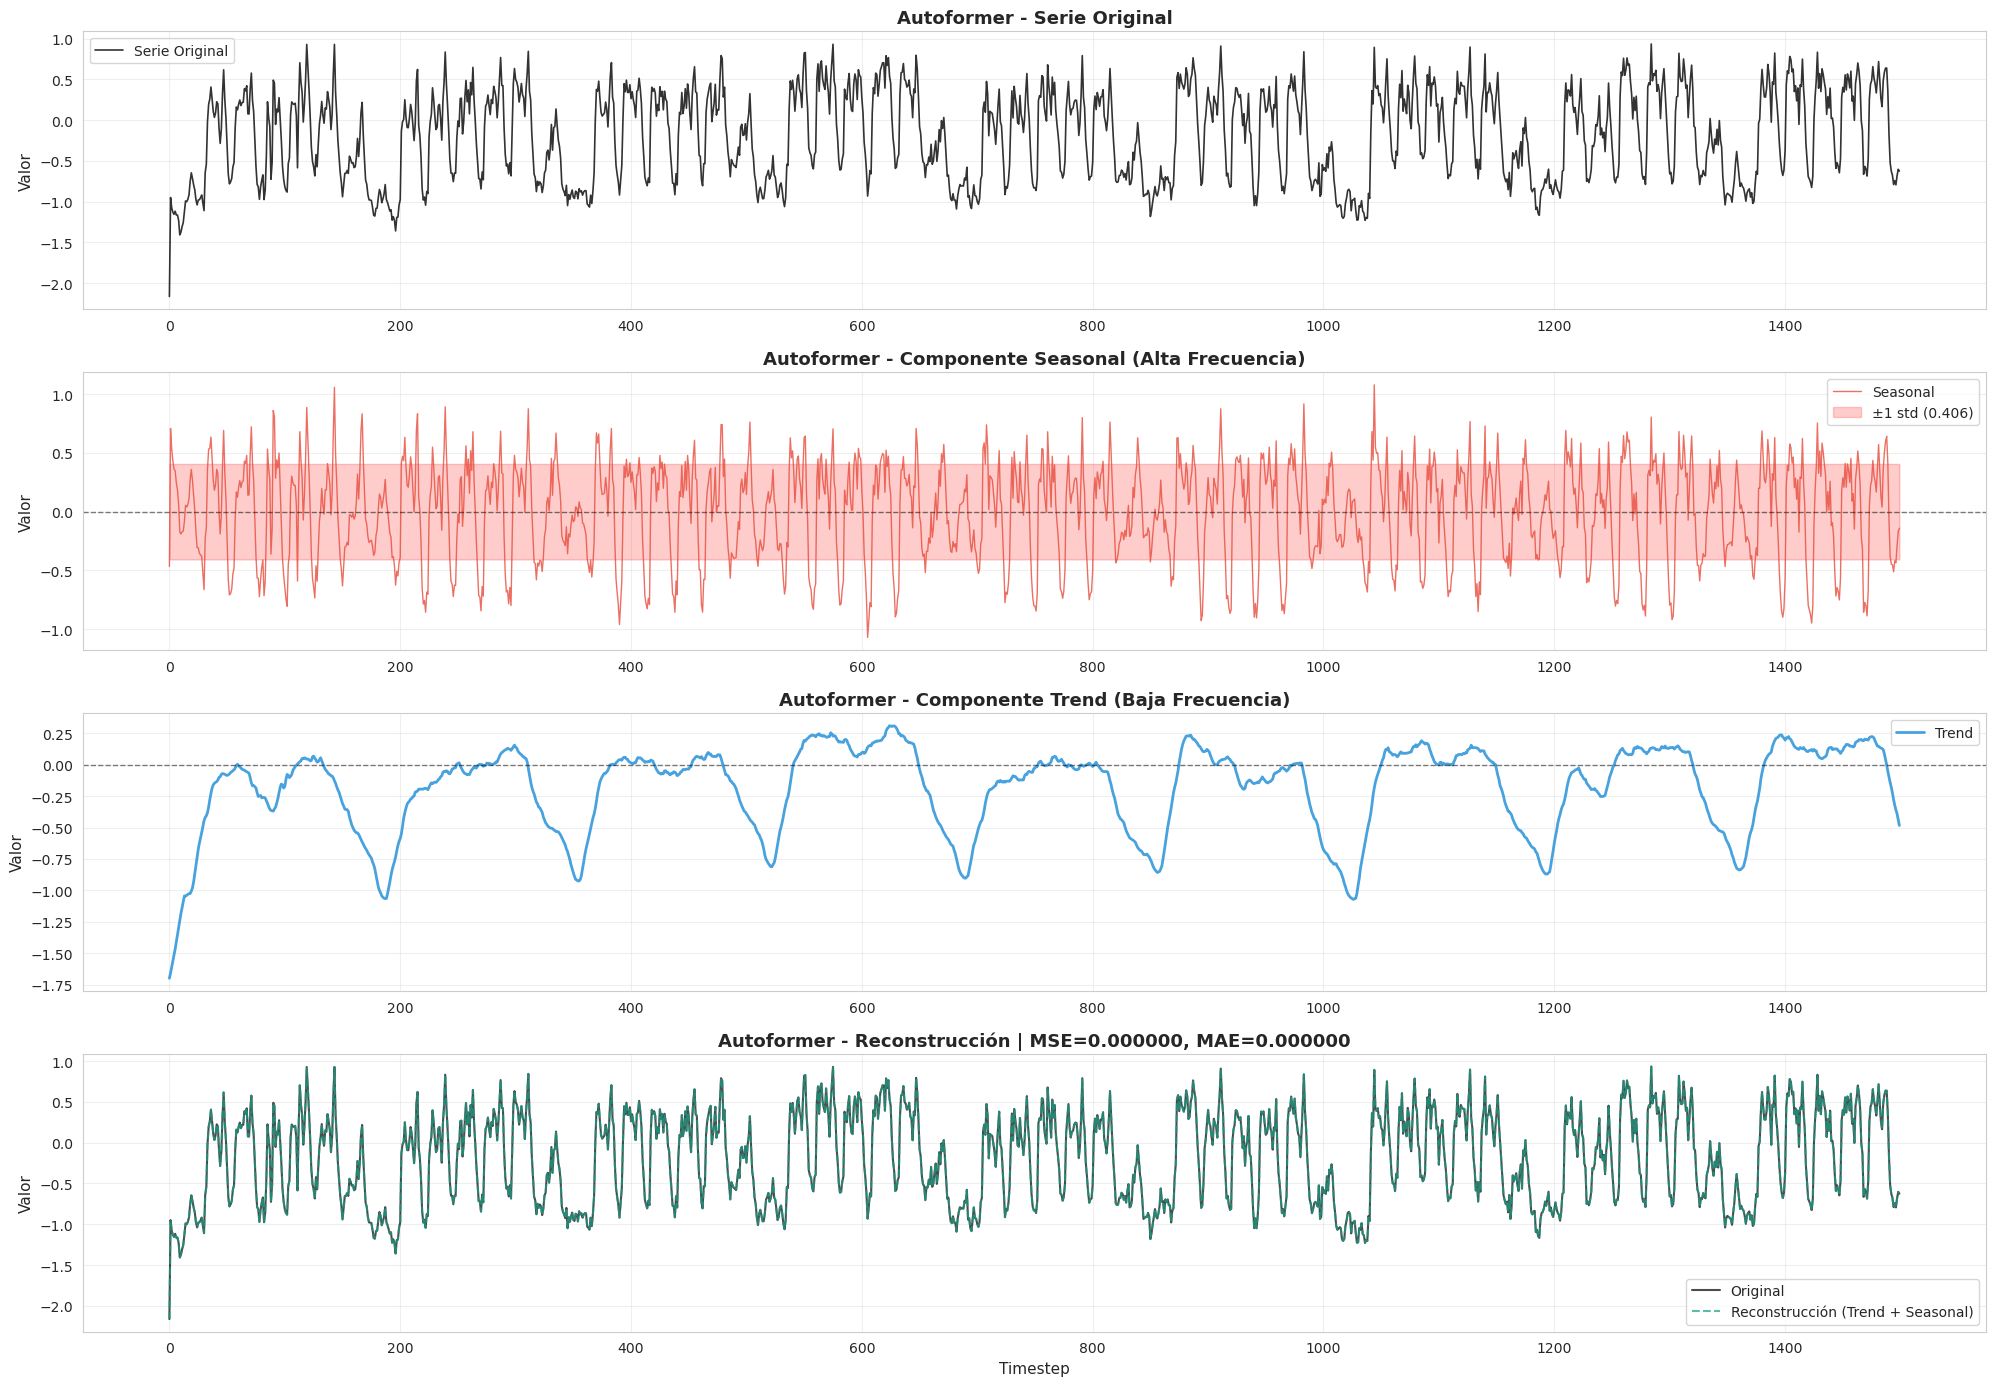

[ESTADÍSTICAS AUTOFORMER]
  Num Tokens: 2 (trend + seasonal)
  Compression Ratio: 750.00
  Kernel Size (promedio móvil): 25 timesteps

  Componente Seasonal:
    Media: 0.001841 (debe ser ~0)
    Std: 0.4057
    Rango: [-1.068, 1.078]

  Componente Trend:
    Media: -0.185148
    Std: 0.3455
    Rango: [-1.698, 0.310]

  Calidad Reconstrucción:
    MSE: 0.00000000
    MAE: 0.00000000
    Max Error Absoluto: 0.00000006


In [14]:
decomp_viz = visualize_decomposition(elec_decomp)

fig, axes = plt.subplots(4, 1, figsize=(20, 14))

# Panel 1: Serie original
axes[0].plot(elec_series, linewidth=1.2, color='black', alpha=0.8, label='Serie Original')
axes[0].set_title('Autoformer - Serie Original', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Componente Seasonal (alta frecuencia)
axes[1].plot(elec_decomp['seasonal'], linewidth=1, color='#E74C3C', alpha=0.8, label='Seasonal')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
seasonal_std = elec_decomp['seasonal'].std()
axes[1].fill_between(range(len(elec_decomp['seasonal'])), -seasonal_std, seasonal_std, 
                     alpha=0.2, color='red', label=f'±1 std ({seasonal_std:.3f})')
axes[1].set_title('Autoformer - Componente Seasonal (Alta Frecuencia)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Valor', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Componente Trend (baja frecuencia)
axes[2].plot(elec_decomp['trend'], linewidth=2, color='#3498DB', alpha=0.9, label='Trend')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_title('Autoformer - Componente Trend (Baja Frecuencia)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Valor', fontsize=11)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

# Panel 4: Reconstrucción vs Original
axes[3].plot(elec_series, linewidth=1.5, color='black', alpha=0.7, label='Original', linestyle='-')
axes[3].plot(decomp_viz['reconstruction'], linewidth=1.5, color='#16A085', alpha=0.7, 
            label='Reconstrucción (Trend + Seasonal)', linestyle='--')
error = np.abs(elec_series - decomp_viz['reconstruction'])
mse = (error ** 2).mean()
mae = error.mean()
axes[3].set_title(f'Autoformer - Reconstrucción | MSE={mse:.6f}, MAE={mae:.6f}', 
                 fontsize=13, fontweight='bold')
axes[3].set_xlabel('Timestep', fontsize=11)
axes[3].set_ylabel('Valor', fontsize=11)
axes[3].legend(fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis espectral
from scipy.fft import fft, fftfreq

print("[ESTADÍSTICAS AUTOFORMER]")
print(f"  Num Tokens: {elec_decomp['num_tokens']} (trend + seasonal)")
print(f"  Compression Ratio: {elec_decomp['compression_ratio']:.2f}")
print(f"  Kernel Size (promedio móvil): 25 timesteps")
print(f"\n  Componente Seasonal:")
print(f"    Media: {elec_decomp['seasonal'].mean():.6f} (debe ser ~0)")
print(f"    Std: {elec_decomp['seasonal'].std():.4f}")
print(f"    Rango: [{elec_decomp['seasonal'].min():.3f}, {elec_decomp['seasonal'].max():.3f}]")
print(f"\n  Componente Trend:")
print(f"    Media: {elec_decomp['trend'].mean():.6f}")
print(f"    Std: {elec_decomp['trend'].std():.4f}")
print(f"    Rango: [{elec_decomp['trend'].min():.3f}, {elec_decomp['trend'].max():.3f}]")
print(f"\n  Calidad Reconstrucción:")
print(f"    MSE: {mse:.8f}")
print(f"    MAE: {mae:.8f}")
print(f"    Max Error Absoluto: {error.max():.8f}")

## MOMENT - Masked Patch Pre-training

**Técnica**: Foundation model con masked reconstruction (Goswami et al., 2024)

**Descripción**:
- Segmenta en patches como PatchTST
- Enmascara 30% de patches aleatoriamente
- Modelo aprende a reconstruir patches enmascarados
- Pre-training self-supervised para foundation model

**Interpretación**:
- Regiones rojas = patches enmascarados (ocultos al modelo)
- Regiones verdes = patches visibles (observados)
- Modelo debe predecir valores en regiones rojas

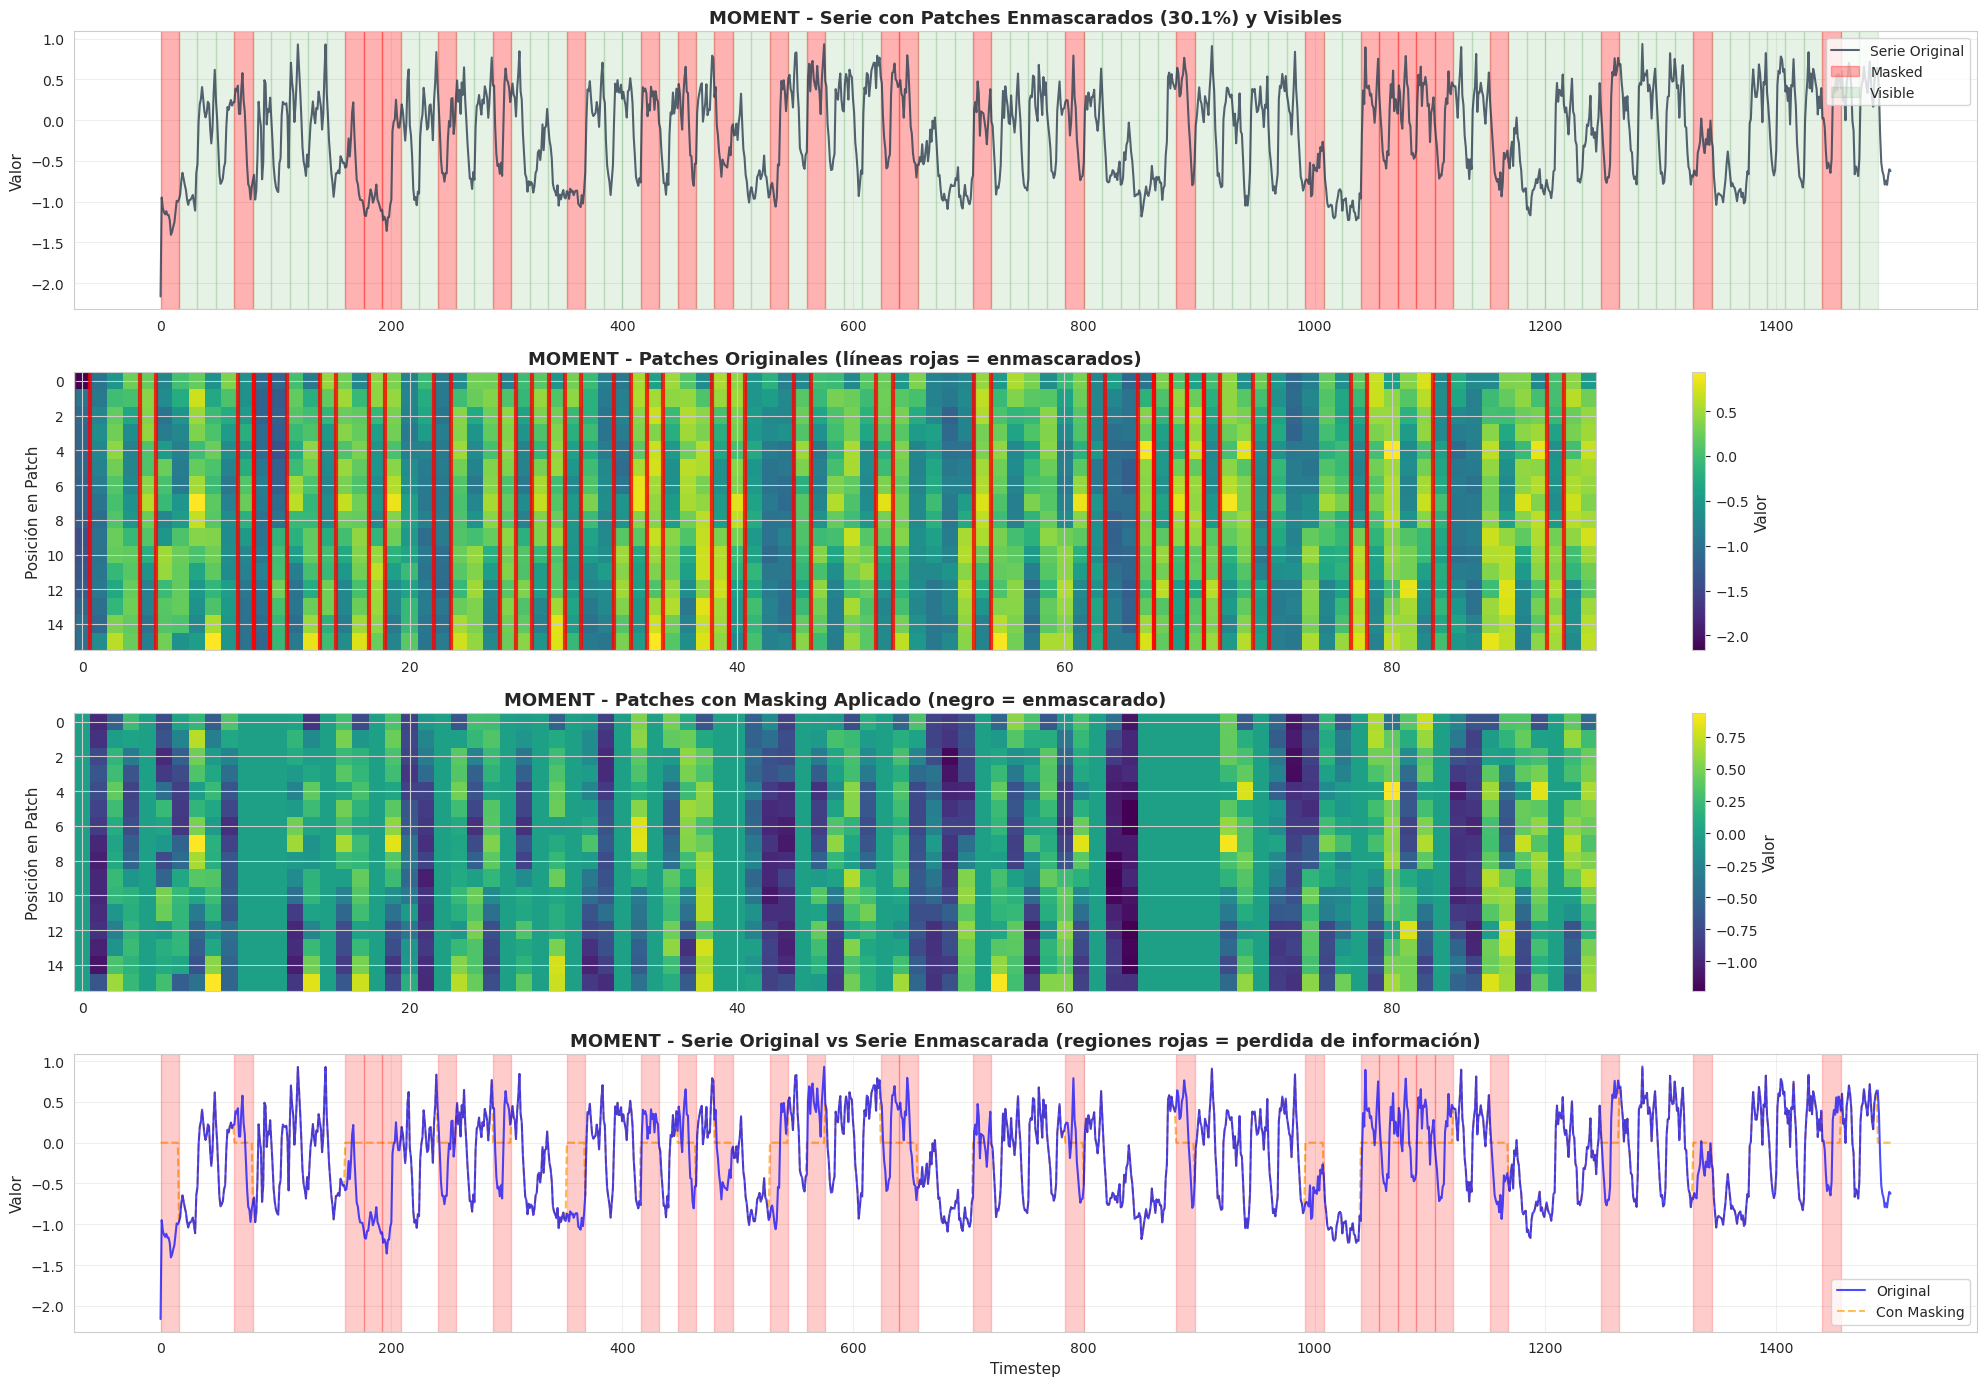

[ESTADÍSTICAS MOMENT]
  Patch Length: 16 timesteps
  Stride: 16 (sin solapamiento)
  Num Patches: 93
  Num Masked: 28
  Mask Ratio: 30.1%
  Compression Ratio: 16.13

  Patches enmascarados (índices): [0, 4, 10, 11, 12, 15, 18, 22, 26, 28, 30, 33, 35, 39, 40, 44, 49, 55, 62, 65, 66, 67, 68, 69, 72, 78, 83, 90]
  Patches visibles (índices): [1, 2, 3, 5, 6, 7, 8, 9, 13, 14, 16, 17, 19, 20, 21, 23, 24, 25, 27, 29, 31, 32, 34, 36, 37, 38, 41, 42, 43, 45, 46, 47, 48, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 63, 64, 70, 71, 73, 74, 75, 76, 77, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 91, 92]

  Información perdida por masking:
    Timesteps enmascarados: 448
    Porcentaje de serie: 29.9%


In [15]:
found_viz = visualize_foundation(elec_series, elec_foundation['patches'], 
                                  elec_foundation['mask'], 16, 16)

fig, axes = plt.subplots(4, 1, figsize=(20, 14))

# Panel 1: Serie con patches enmascarados/visibles
axes[0].plot(elec_series, linewidth=1.5, color='#2C3E50', alpha=0.8, label='Serie Original', zorder=2)
for i, (pos, masked) in enumerate(zip(found_viz['patch_positions'], elec_foundation['mask'])):
    if masked:
        axes[0].axvspan(pos, pos+16, color='red', alpha=0.3, label='Masked' if i == 0 else '')
    else:
        axes[0].axvspan(pos, pos+16, color='green', alpha=0.1, label='Visible' if i == 1 else '')

axes[0].set_title(f'MOMENT - Serie con Patches Enmascarados ({elec_foundation["mask_ratio_actual"]*100:.1f}%) y Visibles', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=11)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Heatmap patches originales
im1 = axes[1].imshow(elec_foundation['patches'].T, aspect='auto', cmap='viridis', interpolation='nearest')
# Marcar patches enmascarados
for i, masked in enumerate(elec_foundation['mask']):
    if masked:
        axes[1].axvline(i-0.5, color='red', linewidth=3, alpha=0.8)
        axes[1].axvline(i+0.5, color='red', linewidth=3, alpha=0.8)
axes[1].set_title('MOMENT - Patches Originales (líneas rojas = enmascarados)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Posición en Patch', fontsize=11)
plt.colorbar(im1, ax=axes[1], label='Valor')

# Panel 3: Heatmap patches enmascarados
im2 = axes[2].imshow(found_viz['masked_patches'].T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[2].set_title(f'MOMENT - Patches con Masking Aplicado (negro = enmascarado)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Posición en Patch', fontsize=11)
plt.colorbar(im2, ax=axes[2], label='Valor')

# Panel 4: Comparación serie original vs enmascarada
axes[3].plot(elec_series, linewidth=1.5, color='blue', alpha=0.7, label='Original', zorder=2)
axes[3].plot(found_viz['reconstructed_masked'], linewidth=1.5, color='orange', alpha=0.7, 
            label='Con Masking', linestyle='--', zorder=1)
# Marcar regiones enmascaradas
for i, (pos, masked) in enumerate(zip(found_viz['patch_positions'], elec_foundation['mask'])):
    if masked:
        axes[3].axvspan(pos, pos+16, color='red', alpha=0.2)

axes[3].set_title('MOMENT - Serie Original vs Serie Enmascarada (regiones rojas = perdida de información)', 
                 fontsize=13, fontweight='bold')
axes[3].set_xlabel('Timestep', fontsize=11)
axes[3].set_ylabel('Valor', fontsize=11)
axes[3].legend(fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS MOMENT]")
print(f"  Patch Length: 16 timesteps")
print(f"  Stride: 16 (sin solapamiento)")
print(f"  Num Patches: {elec_foundation['num_patches']}")
print(f"  Num Masked: {elec_foundation['num_masked']}")
print(f"  Mask Ratio: {elec_foundation['mask_ratio_actual']*100:.1f}%")
print(f"  Compression Ratio: {elec_foundation['compression_ratio']:.2f}")
print(f"\n  Patches enmascarados (índices): {np.where(elec_foundation['mask'])[0].tolist()}")
print(f"  Patches visibles (índices): {np.where(~elec_foundation['mask'])[0].tolist()}")
print(f"\n  Información perdida por masking:")
print(f"    Timesteps enmascarados: {elec_foundation['num_masked'] * 16}")
print(f"    Porcentaje de serie: {elec_foundation['num_masked'] * 16 / len(elec_series) * 100:.1f}%")

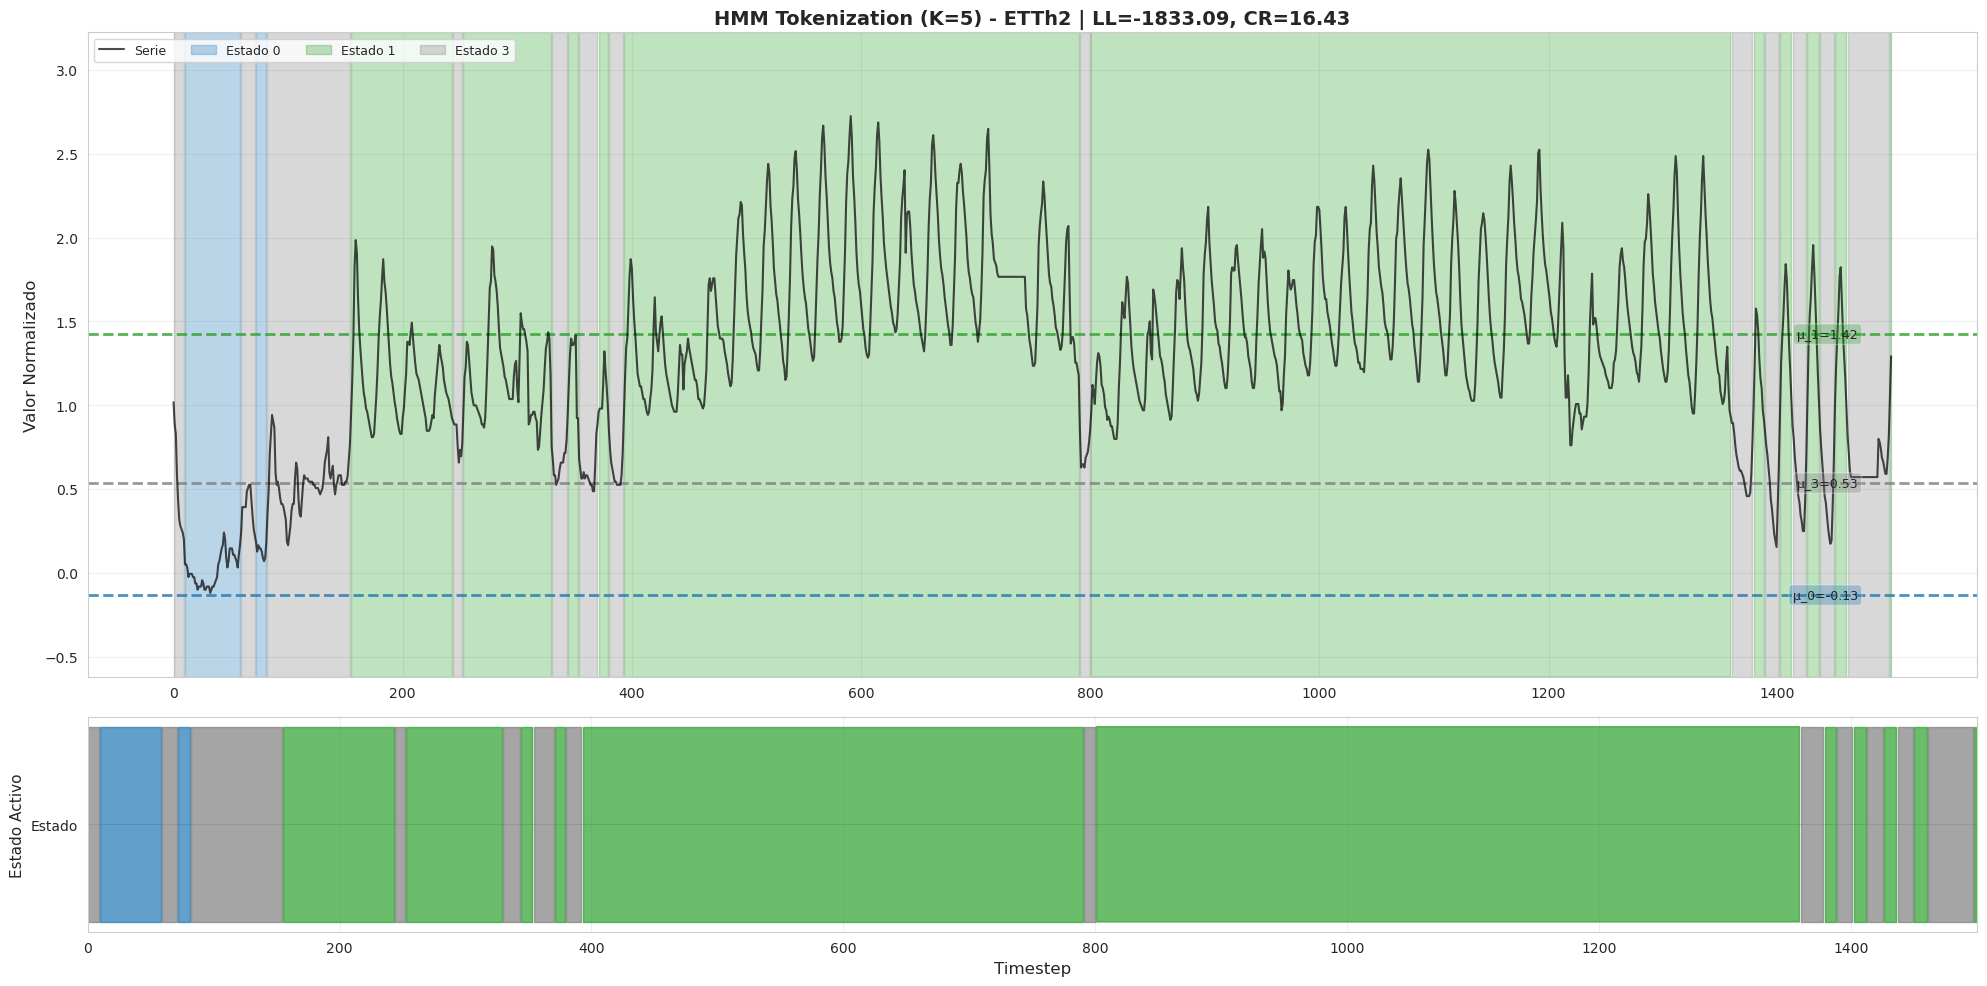

[ESTADÍSTICAS HMM - ETTh2]
  Número de estados (K): 5
  Estados únicos usados: 3
  Compression Ratio: 16.43
  Número de segmentos: 526
  Duración promedio segmento: 16.43 timesteps
  Entropía estados: 1.603 (max=1.609)

  Parámetros por estado:
    Estado 0: μ=-0.133, σ=0.201, freq=3.9% (59 timesteps)
    Estado 1: μ=1.424, σ=0.388, freq=79.1% (1187 timesteps)
    Estado 2: μ=-1.387, σ=0.222, freq=0.0% (0 timesteps)
    Estado 3: μ=0.535, σ=0.222, freq=16.9% (254 timesteps)
    Estado 4: μ=-0.825, σ=0.182, freq=0.0% (0 timesteps)


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(etth2_series, linewidth=1.5, color='black', alpha=0.7, label='Serie', zorder=3)

colors = plt.cm.tab10(np.linspace(0, 1, K_SELECTED))
for k in range(K_SELECTED):
    mask = etth2_states_vis == k
    if mask.any():
        ax1.fill_between(range(len(etth2_series)), etth2_series.min()-0.5, etth2_series.max()+0.5, 
                         where=mask, color=colors[k], alpha=0.3, label=f'Estado {k}')
        mu_k = etth2_params['mu'][k]
        ax1.axhline(mu_k, color=colors[k], linestyle='--', linewidth=2, alpha=0.8)
        ax1.text(len(etth2_series)*0.98, mu_k, f'μ_{k}={mu_k:.2f}', 
                ha='right', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor=colors[k], alpha=0.3))

ax1.set_title(f'HMM Tokenization (K={K_SELECTED}) - ETTh2 | LL={hmm_etth2["log_likelihood"]:.2f}, CR={hmm_etth2["compression_ratio"]:.2f}', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=12)
ax1.legend(loc='upper left', ncol=K_SELECTED+1, fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(etth2_series.min()-0.5, etth2_series.max()+0.5)

for k in range(K_SELECTED):
    mask = etth2_states_vis == k
    ax2.fill_between(range(len(etth2_series)), 0, 1, where=mask, color=colors[k], alpha=0.7)

ax2.set_xlabel('Timestep', fontsize=12)
ax2.set_ylabel('Estado Activo', fontsize=11)
ax2.set_yticks([0.5])
ax2.set_yticklabels(['Estado'], fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0, len(etth2_series))

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS HMM - ETTh2]")
print(f"  Número de estados (K): {K_SELECTED}")
print(f"  Estados únicos usados: {len(np.unique(etth2_states_vis))}")
print(f"  Compression Ratio: {hmm_etth2['compression_ratio']:.2f}")
print(f"  Número de segmentos: {hmm_etth2['n_segments']}")
print(f"  Duración promedio segmento: {hmm_etth2['avg_segment_duration']:.2f} timesteps")
print(f"  Entropía estados: {hmm_etth2['state_entropy']:.3f} (max={np.log(K_SELECTED):.3f})")
print(f"\n  Parámetros por estado:")
for k in range(K_SELECTED):
    count = (etth2_states_vis == k).sum()
    pct = count / len(etth2_states_vis) * 100
    print(f"    Estado {k}: μ={etth2_params['mu'][k]:.3f}, σ={etth2_params['sigma'][k]:.3f}, freq={pct:.1f}% ({count} timesteps)")

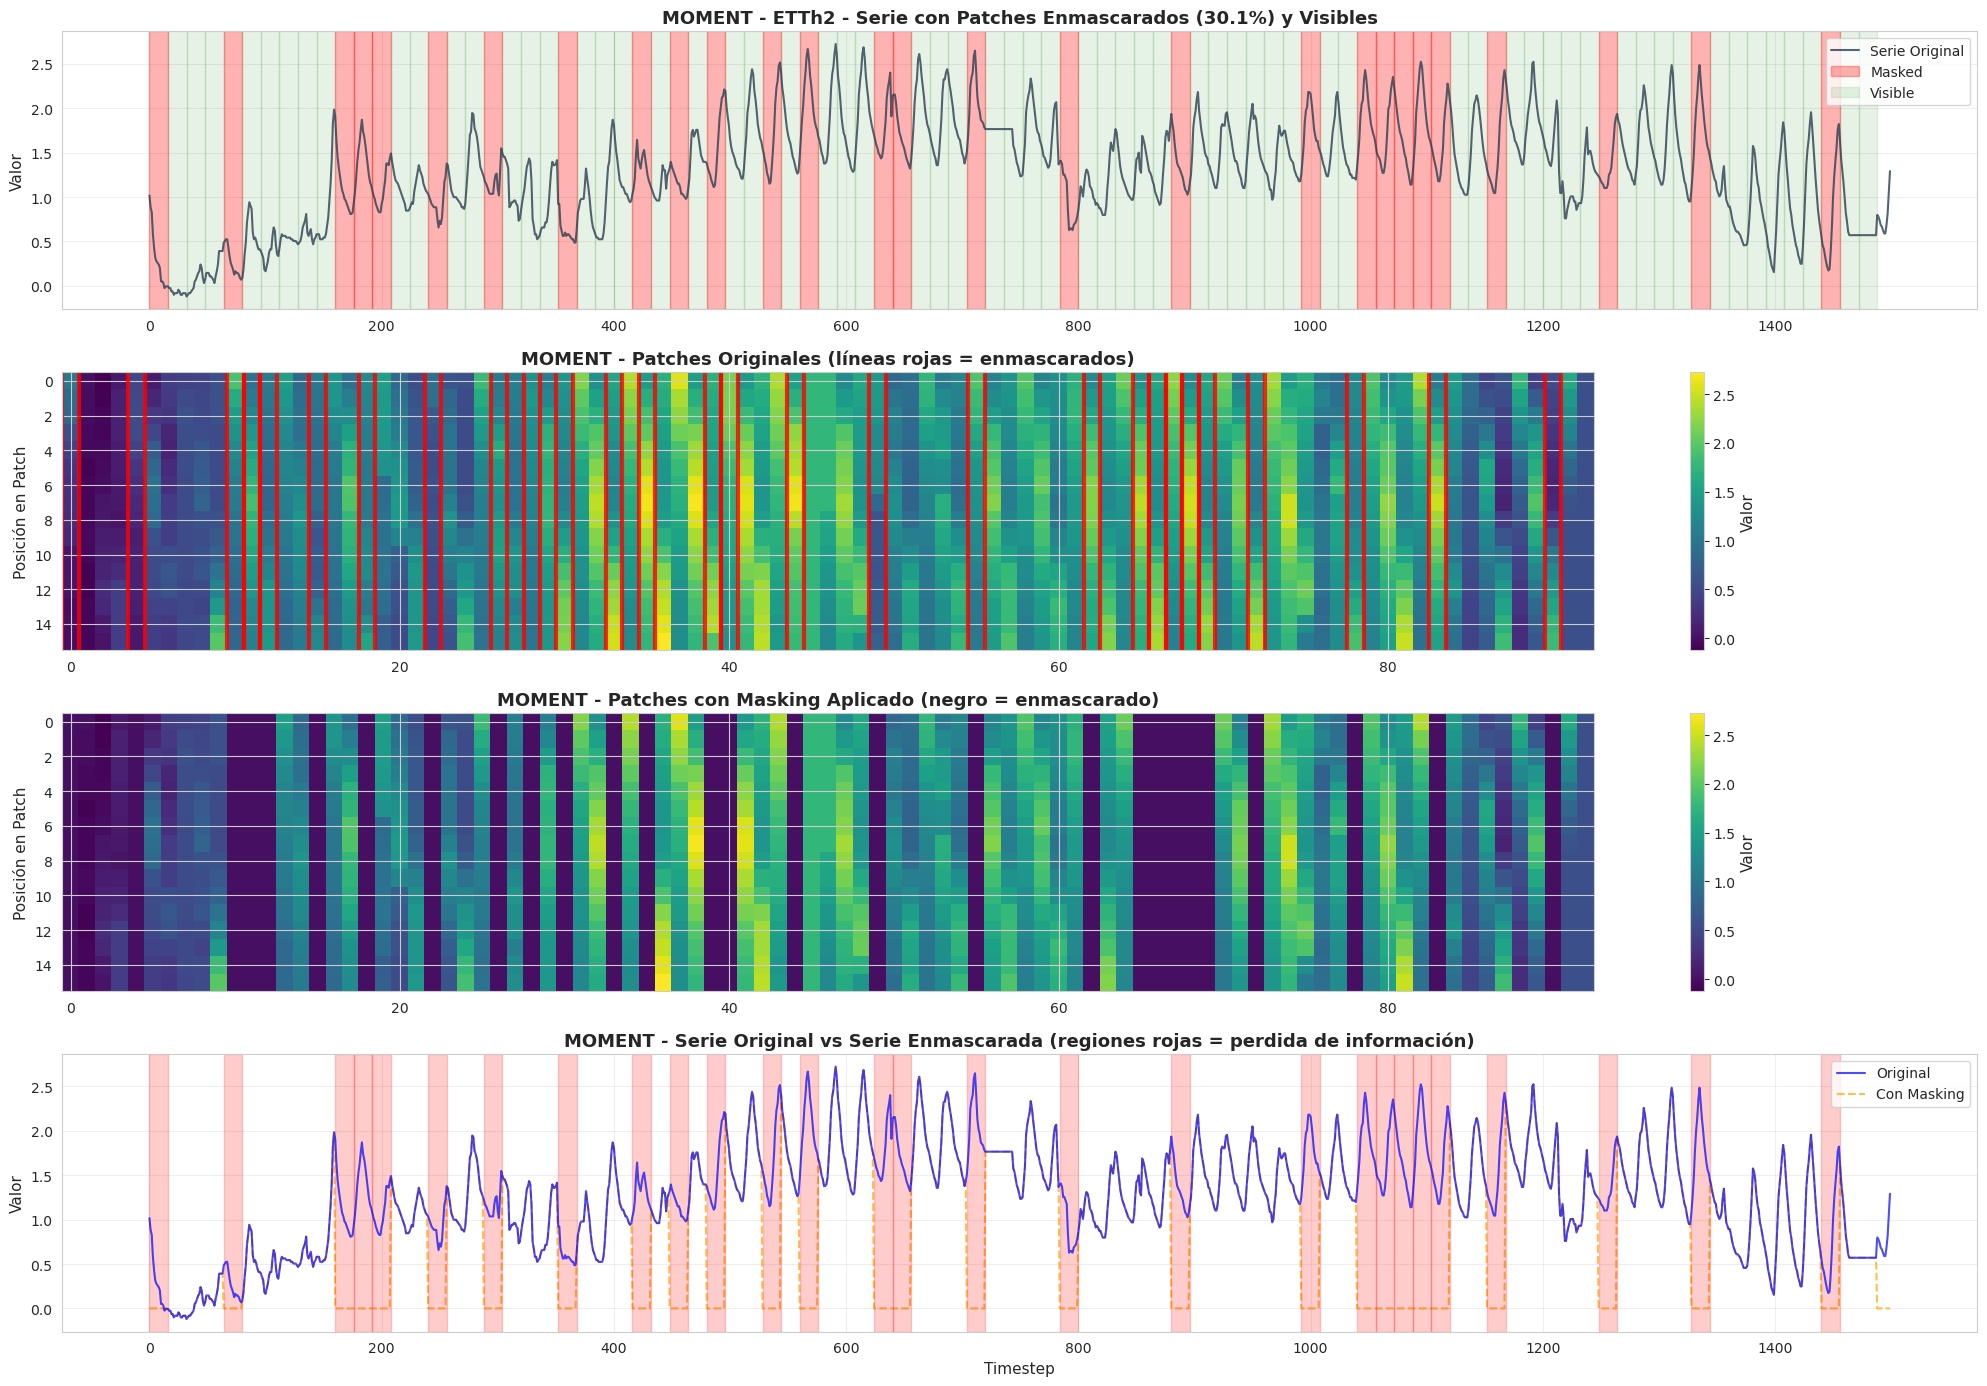

[ESTADÍSTICAS MOMENT - ETTh2]
  Patch Length: 16 timesteps
  Stride: 16 (sin solapamiento)
  Num Patches: 93
  Num Masked: 28
  Mask Ratio: 30.1%
  Compression Ratio: 16.13

  Patches enmascarados (índices): [0, 4, 10, 11, 12, 15, 18, 22, 26, 28, 30, 33, 35, 39, 40, 44, 49, 55, 62, 65, 66, 67, 68, 69, 72, 78, 83, 90]
  Patches visibles (índices): [1, 2, 3, 5, 6, 7, 8, 9, 13, 14, 16, 17, 19, 20, 21, 23, 24, 25, 27, 29, 31, 32, 34, 36, 37, 38, 41, 42, 43, 45, 46, 47, 48, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 63, 64, 70, 71, 73, 74, 75, 76, 77, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 91, 92]

  Información perdida por masking:
    Timesteps enmascarados: 448
    Porcentaje de serie: 29.9%


In [17]:
found_viz = visualize_foundation(etth2_series, etth2_foundation['patches'], 
                                  etth2_foundation['mask'], 16, 16)

fig, axes = plt.subplots(4, 1, figsize=(20, 14))

axes[0].plot(etth2_series, linewidth=1.5, color='#2C3E50', alpha=0.8, label='Serie Original', zorder=2)
for i, (pos, masked) in enumerate(zip(found_viz['patch_positions'], etth2_foundation['mask'])):
    if masked:
        axes[0].axvspan(pos, pos+16, color='red', alpha=0.3, label='Masked' if i == 0 else '')
    else:
        axes[0].axvspan(pos, pos+16, color='green', alpha=0.1, label='Visible' if i == 1 else '')

axes[0].set_title(f'MOMENT - ETTh2 - Serie con Patches Enmascarados ({etth2_foundation["mask_ratio_actual"]*100:.1f}%) y Visibles', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=11)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)

im1 = axes[1].imshow(etth2_foundation['patches'].T, aspect='auto', cmap='viridis', interpolation='nearest')
for i, masked in enumerate(etth2_foundation['mask']):
    if masked:
        axes[1].axvline(i-0.5, color='red', linewidth=3, alpha=0.8)
        axes[1].axvline(i+0.5, color='red', linewidth=3, alpha=0.8)
axes[1].set_title('MOMENT - Patches Originales (líneas rojas = enmascarados)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Posición en Patch', fontsize=11)
plt.colorbar(im1, ax=axes[1], label='Valor')

im2 = axes[2].imshow(found_viz['masked_patches'].T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[2].set_title(f'MOMENT - Patches con Masking Aplicado (negro = enmascarado)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Posición en Patch', fontsize=11)
plt.colorbar(im2, ax=axes[2], label='Valor')

axes[3].plot(etth2_series, linewidth=1.5, color='blue', alpha=0.7, label='Original', zorder=2)
axes[3].plot(found_viz['reconstructed_masked'], linewidth=1.5, color='orange', alpha=0.7, 
            label='Con Masking', linestyle='--', zorder=1)
for i, (pos, masked) in enumerate(zip(found_viz['patch_positions'], etth2_foundation['mask'])):
    if masked:
        axes[3].axvspan(pos, pos+16, color='red', alpha=0.2)

axes[3].set_title('MOMENT - Serie Original vs Serie Enmascarada (regiones rojas = perdida de información)', 
                 fontsize=13, fontweight='bold')
axes[3].set_xlabel('Timestep', fontsize=11)
axes[3].set_ylabel('Valor', fontsize=11)
axes[3].legend(fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS MOMENT - ETTh2]")
print(f"  Patch Length: 16 timesteps")
print(f"  Stride: 16 (sin solapamiento)")
print(f"  Num Patches: {etth2_foundation['num_patches']}")
print(f"  Num Masked: {etth2_foundation['num_masked']}")
print(f"  Mask Ratio: {etth2_foundation['mask_ratio_actual']*100:.1f}%")
print(f"  Compression Ratio: {etth2_foundation['compression_ratio']:.2f}")
print(f"\n  Patches enmascarados (índices): {np.where(etth2_foundation['mask'])[0].tolist()}")
print(f"  Patches visibles (índices): {np.where(~etth2_foundation['mask'])[0].tolist()}")
print(f"\n  Información perdida por masking:")
print(f"    Timesteps enmascarados: {etth2_foundation['num_masked'] * 16}")
print(f"    Porcentaje de serie: {etth2_foundation['num_masked'] * 16 / len(etth2_series) * 100:.1f}%")

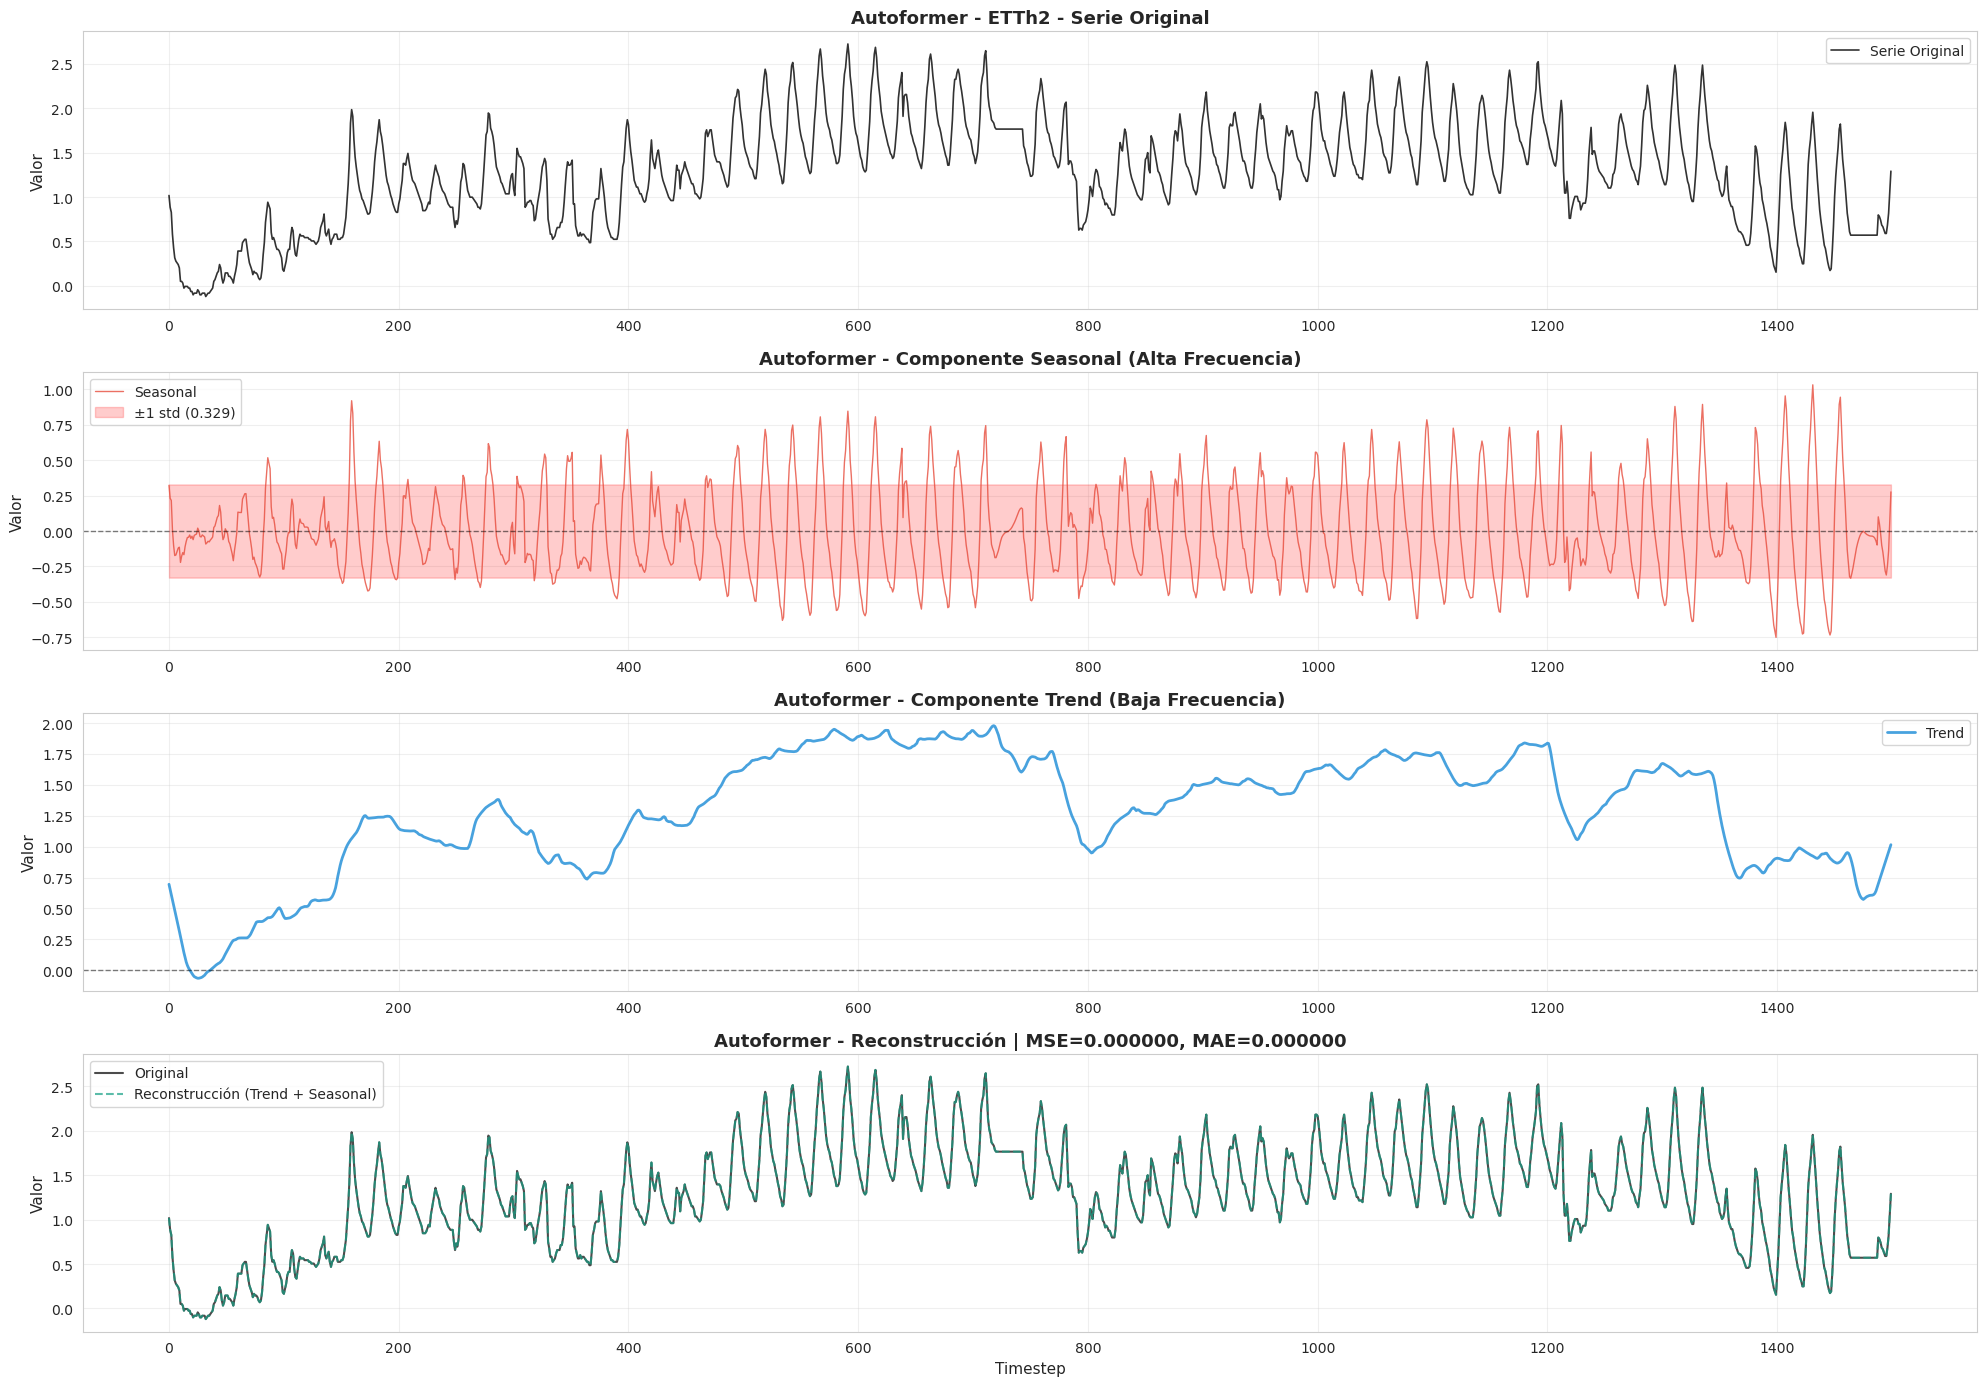

[ESTADÍSTICAS AUTOFORMER - ETTh2]
  Num Tokens: 2 (trend + seasonal)
  Compression Ratio: 750.00
  Kernel Size (promedio móvil): 25 timesteps

  Componente Seasonal:
    Media: -0.001860 (debe ser ~0)
    Std: 0.3286
    Rango: [-0.750, 1.032]

  Componente Trend:
    Media: 1.294683
    Std: 0.4670
    Rango: [-0.065, 1.978]

  Calidad Reconstrucción:
    MSE: 0.00000000
    MAE: 0.00000000
    Max Error Absoluto: 0.00000003


In [18]:
decomp_viz = visualize_decomposition(etth2_decomp)

fig, axes = plt.subplots(4, 1, figsize=(20, 14))

axes[0].plot(etth2_series, linewidth=1.2, color='black', alpha=0.8, label='Serie Original')
axes[0].set_title('Autoformer - ETTh2 - Serie Original', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(etth2_decomp['seasonal'], linewidth=1, color='#E74C3C', alpha=0.8, label='Seasonal')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
seasonal_std = etth2_decomp['seasonal'].std()
axes[1].fill_between(range(len(etth2_decomp['seasonal'])), -seasonal_std, seasonal_std, 
                     alpha=0.2, color='red', label=f'±1 std ({seasonal_std:.3f})')
axes[1].set_title('Autoformer - Componente Seasonal (Alta Frecuencia)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Valor', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

axes[2].plot(etth2_decomp['trend'], linewidth=2, color='#3498DB', alpha=0.9, label='Trend')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_title('Autoformer - Componente Trend (Baja Frecuencia)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Valor', fontsize=11)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

axes[3].plot(etth2_series, linewidth=1.5, color='black', alpha=0.7, label='Original', linestyle='-')
axes[3].plot(decomp_viz['reconstruction'], linewidth=1.5, color='#16A085', alpha=0.7, 
            label='Reconstrucción (Trend + Seasonal)', linestyle='--')
error = np.abs(etth2_series - decomp_viz['reconstruction'])
mse = (error ** 2).mean()
mae = error.mean()
axes[3].set_title(f'Autoformer - Reconstrucción | MSE={mse:.6f}, MAE={mae:.6f}', 
                 fontsize=13, fontweight='bold')
axes[3].set_xlabel('Timestep', fontsize=11)
axes[3].set_ylabel('Valor', fontsize=11)
axes[3].legend(fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS AUTOFORMER - ETTh2]")
print(f"  Num Tokens: {etth2_decomp['num_tokens']} (trend + seasonal)")
print(f"  Compression Ratio: {etth2_decomp['compression_ratio']:.2f}")
print(f"  Kernel Size (promedio móvil): 25 timesteps")
print(f"\n  Componente Seasonal:")
print(f"    Media: {etth2_decomp['seasonal'].mean():.6f} (debe ser ~0)")
print(f"    Std: {etth2_decomp['seasonal'].std():.4f}")
print(f"    Rango: [{etth2_decomp['seasonal'].min():.3f}, {etth2_decomp['seasonal'].max():.3f}]")
print(f"\n  Componente Trend:")
print(f"    Media: {etth2_decomp['trend'].mean():.6f}")
print(f"    Std: {etth2_decomp['trend'].std():.4f}")
print(f"    Rango: [{etth2_decomp['trend'].min():.3f}, {etth2_decomp['trend'].max():.3f}]")
print(f"\n  Calidad Reconstrucción:")
print(f"    MSE: {mse:.8f}")
print(f"    MAE: {mae:.8f}")
print(f"    Max Error Absoluto: {error.max():.8f}")

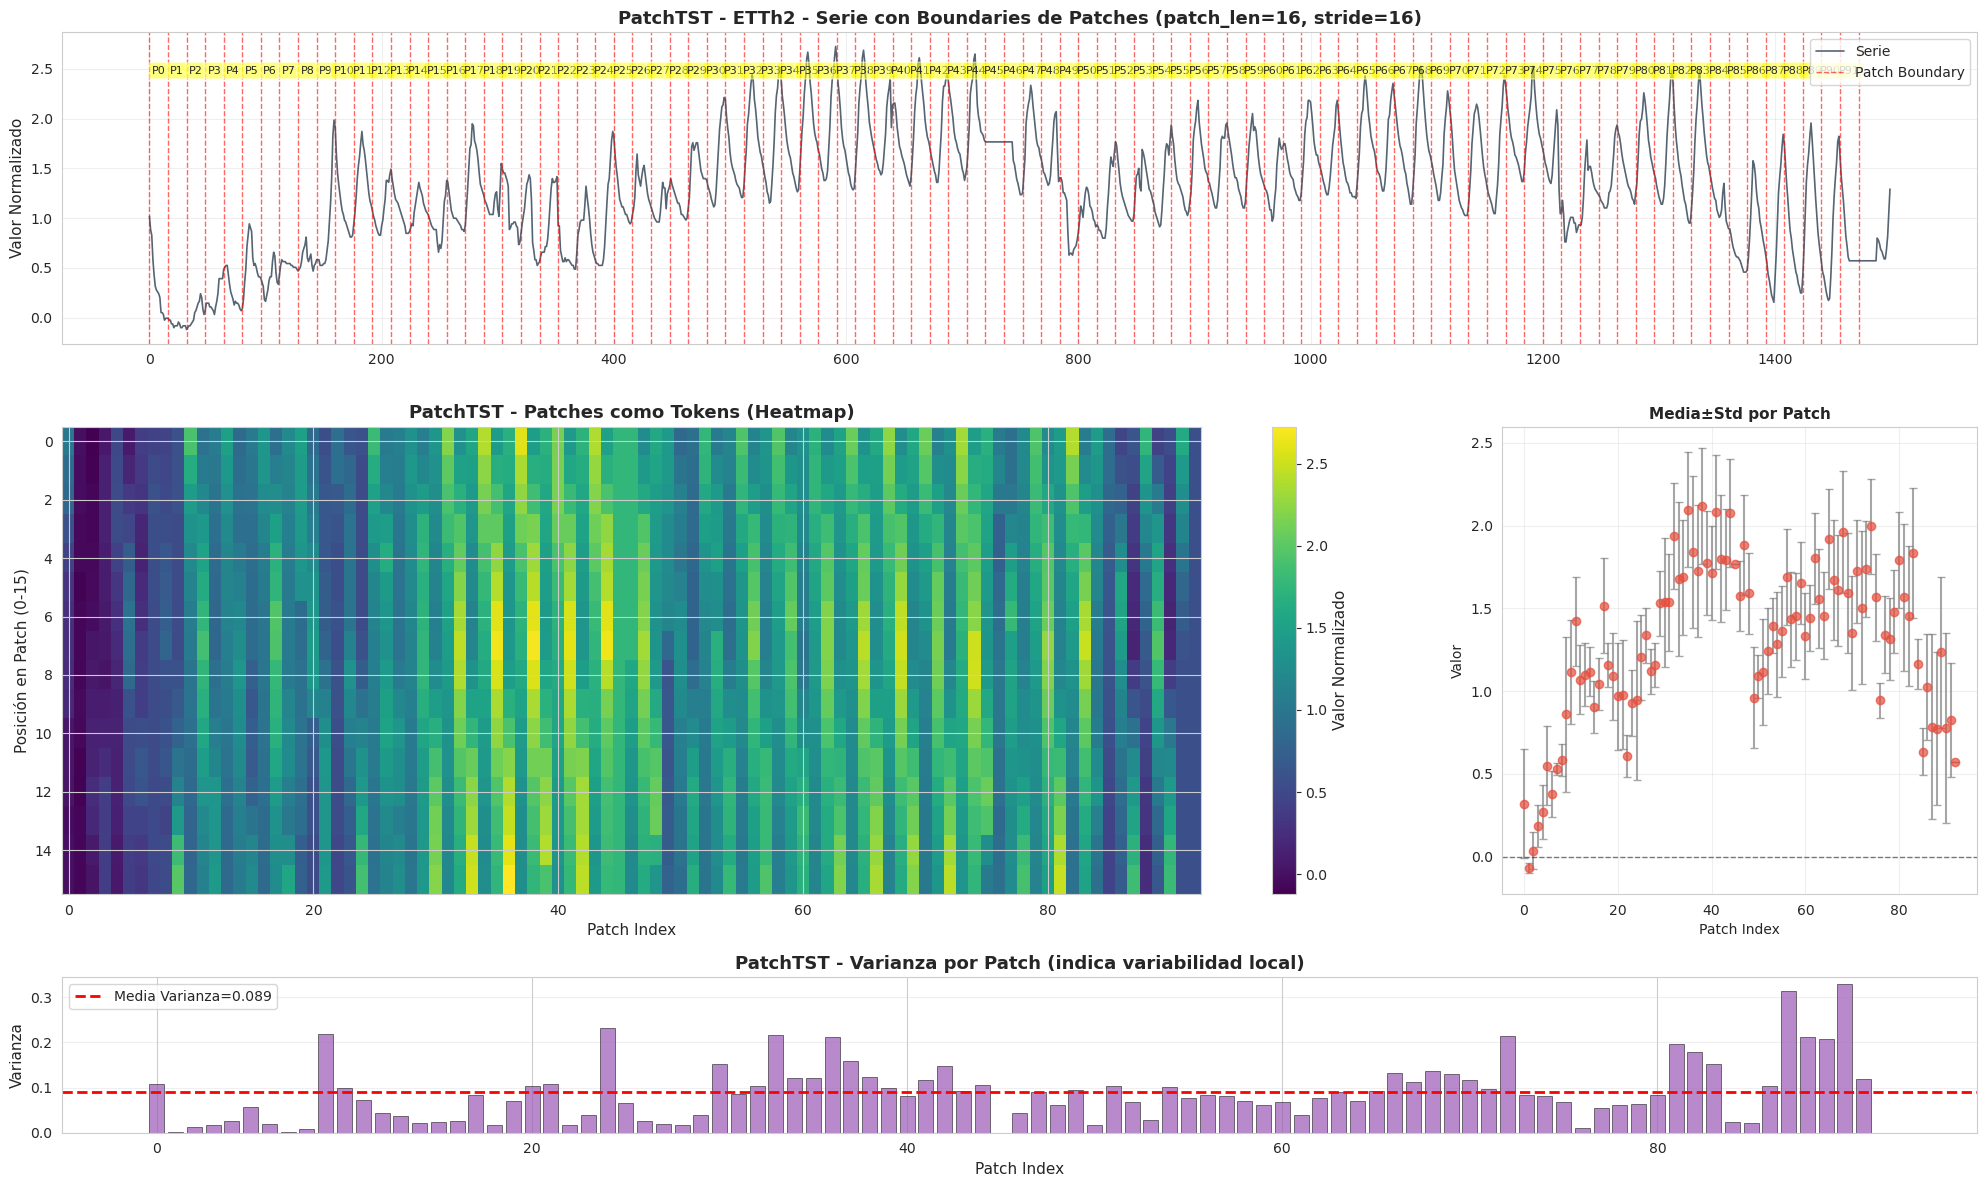

[ESTADÍSTICAS PATCHTST - ETTh2]
  Patch Length: 16 timesteps
  Stride: 16 (sin solapamiento)
  Num Patches: 93
  Compression Ratio: 16.13
  Timesteps cubiertos: 1488
  Timesteps descartados: 12

  Estadísticas de patches:
    Media de varianzas: 0.0891
    Std de varianzas: 0.0667
    Patch más variable: índice 90 (var=0.3281)
    Patch menos variable: índice 45 (var=0.0000)


In [19]:
patch_viz = visualize_patches(etth2_series, etth2_patch_array, 16, 16)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 3, 1], width_ratios=[3, 1])

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, :])

ax1.plot(etth2_series, linewidth=1.2, color='#2C3E50', alpha=0.8, label='Serie')
for i, pos in enumerate(patch_viz['positions']):
    ax1.axvline(pos, color='red', linestyle='--', linewidth=1, alpha=0.6, 
                label='Patch Boundary' if i == 0 else '')
    if i < len(patch_viz['positions']) - 1:
        mid_pos = pos + 8
        ax1.text(mid_pos, etth2_series.max()*0.9, f'P{i}', ha='center', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax1.set_title(f'PatchTST - ETTh2 - Serie con Boundaries de Patches (patch_len=16, stride=16)', 
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

im = ax2.imshow(etth2_patch_array.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax2.set_title('PatchTST - Patches como Tokens (Heatmap)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Patch Index', fontsize=11)
ax2.set_ylabel('Posición en Patch (0-15)', fontsize=11)
plt.colorbar(im, ax=ax2, label='Valor Normalizado')

patch_means = etth2_patch_array.mean(axis=1)
patch_stds = etth2_patch_array.std(axis=1)
ax3.errorbar(range(len(patch_means)), patch_means, yerr=patch_stds, 
             fmt='o', color='#E74C3C', ecolor='gray', alpha=0.7, capsize=3)
ax3.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_title('Media±Std por Patch', fontsize=11, fontweight='bold')
ax3.set_xlabel('Patch Index', fontsize=10)
ax3.set_ylabel('Valor', fontsize=10)
ax3.grid(True, alpha=0.3)

patch_vars = etth2_patch_array.var(axis=1)
ax4.bar(range(len(patch_vars)), patch_vars, color='#9B59B6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axhline(patch_vars.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Media Varianza={patch_vars.mean():.3f}')
ax4.set_xlabel('Patch Index', fontsize=11)
ax4.set_ylabel('Varianza', fontsize=11)
ax4.set_title('PatchTST - Varianza por Patch (indica variabilidad local)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS PATCHTST - ETTh2]")
print(f"  Patch Length: 16 timesteps")
print(f"  Stride: 16 (sin solapamiento)")
print(f"  Num Patches: {patch_viz['num_patches']}")
print(f"  Compression Ratio: {patch_viz['compression_ratio']:.2f}")
print(f"  Timesteps cubiertos: {patch_viz['num_patches'] * 16}")
print(f"  Timesteps descartados: {len(etth2_series) - patch_viz['num_patches'] * 16}")
print(f"\n  Estadísticas de patches:")
print(f"    Media de varianzas: {patch_vars.mean():.4f}")
print(f"    Std de varianzas: {patch_vars.std():.4f}")
print(f"    Patch más variable: índice {patch_vars.argmax()} (var={patch_vars.max():.4f})")
print(f"    Patch menos variable: índice {patch_vars.argmin()} (var={patch_vars.min():.4f})")

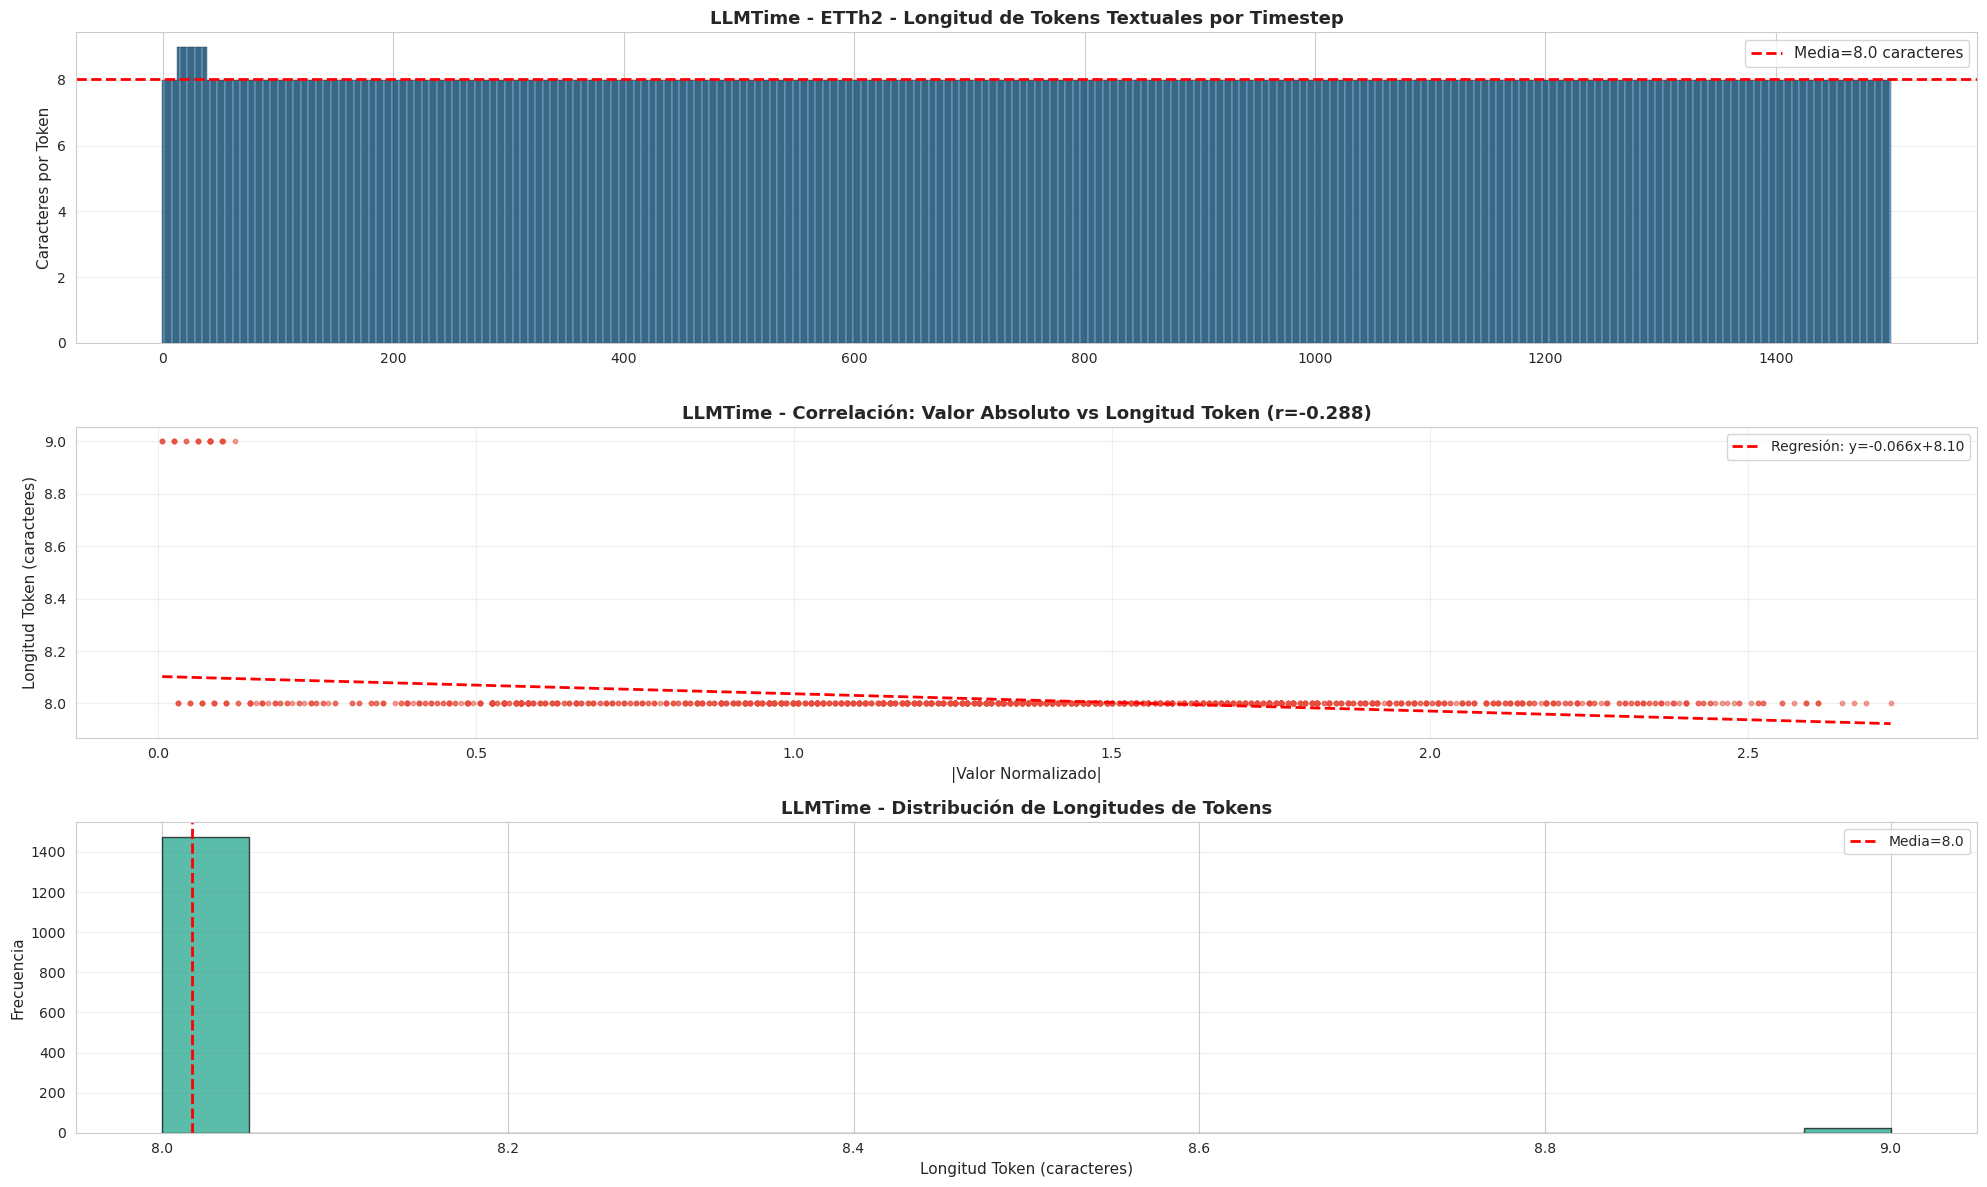

[ESTADÍSTICAS LLMTIME - ETTh2]
  Total caracteres: 12026
  Avg longitud token: 8.02 caracteres
  Compression Ratio: 0.099840 (expansión, no compresión)
  Vocabulary Size: 13 (dígitos 0-9 + signo + punto + separador)

  Ejemplos de serialización (primeros 10 timesteps):
    t=  0: valor= +1.018 → ' 1 . 0 1'
    t=  1: valor= +0.885 → ' 0 . 8 8'
    t=  2: valor= +0.828 → ' 0 . 8 3'
    t=  3: valor= +0.581 → ' 0 . 5 7'
    t=  4: valor= +0.430 → ' 0 . 4 3'
    t=  5: valor= +0.316 → ' 0 . 3 1'
    t=  6: valor= +0.278 → ' 0 . 2 7'
    t=  7: valor= +0.259 → ' 0 . 2 5'
    t=  8: valor= +0.240 → ' 0 . 2 3'
    t=  9: valor= +0.202 → ' 0 . 2 0'


In [20]:
text_viz = visualize_text_based(etth2_series, etth2_text['tokens_per_value'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 12))

ax1.bar(range(len(text_viz['token_lengths'])), text_viz['token_lengths'], 
       color='#3498DB', alpha=0.7, edgecolor='black', linewidth=0.3, width=1)
ax1.axhline(text_viz['avg_token_length'], color='red', linestyle='--', 
           linewidth=2, label=f"Media={text_viz['avg_token_length']:.1f} caracteres")

ax1.set_title('LLMTime - ETTh2 - Longitud de Tokens Textuales por Timestep', fontsize=13, fontweight='bold')
ax1.set_ylabel('Caracteres por Token', fontsize=11)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

abs_values = np.abs(etth2_series)
ax2.scatter(abs_values, text_viz['token_lengths'], alpha=0.5, s=10, color='#E74C3C')
z = np.polyfit(abs_values, text_viz['token_lengths'], 1)
p = np.poly1d(z)
x_line = np.linspace(abs_values.min(), abs_values.max(), 100)
ax2.plot(x_line, p(x_line), "r--", linewidth=2, label=f'Regresión: y={z[0]:.3f}x+{z[1]:.2f}')

corr = np.corrcoef(abs_values, text_viz['token_lengths'])[0, 1]
ax2.set_title(f'LLMTime - Correlación: Valor Absoluto vs Longitud Token (r={corr:.3f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('|Valor Normalizado|', fontsize=11)
ax2.set_ylabel('Longitud Token (caracteres)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

ax3.hist(text_viz['token_lengths'], bins=20, color='#16A085', alpha=0.7, edgecolor='black')
ax3.axvline(text_viz['avg_token_length'], color='red', linestyle='--', linewidth=2, 
           label=f"Media={text_viz['avg_token_length']:.1f}")
ax3.set_xlabel('Longitud Token (caracteres)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.set_title('LLMTime - Distribución de Longitudes de Tokens', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS LLMTIME - ETTh2]")
print(f"  Total caracteres: {text_viz['total_characters']}")
print(f"  Avg longitud token: {text_viz['avg_token_length']:.2f} caracteres")
print(f"  Compression Ratio: {etth2_text['compression_ratio']:.6f} (expansión, no compresión)")
print(f"  Vocabulary Size: {etth2_text['vocabulary_size']} (dígitos 0-9 + signo + punto + separador)")
print(f"\n  Ejemplos de serialización (primeros 10 timesteps):")
for i in range(min(10, len(etth2_text['tokens_per_value']))):
    print(f"    t={i:3d}: valor={etth2_series[i]:+7.3f} → '{etth2_text['tokens_per_value'][i]}'")

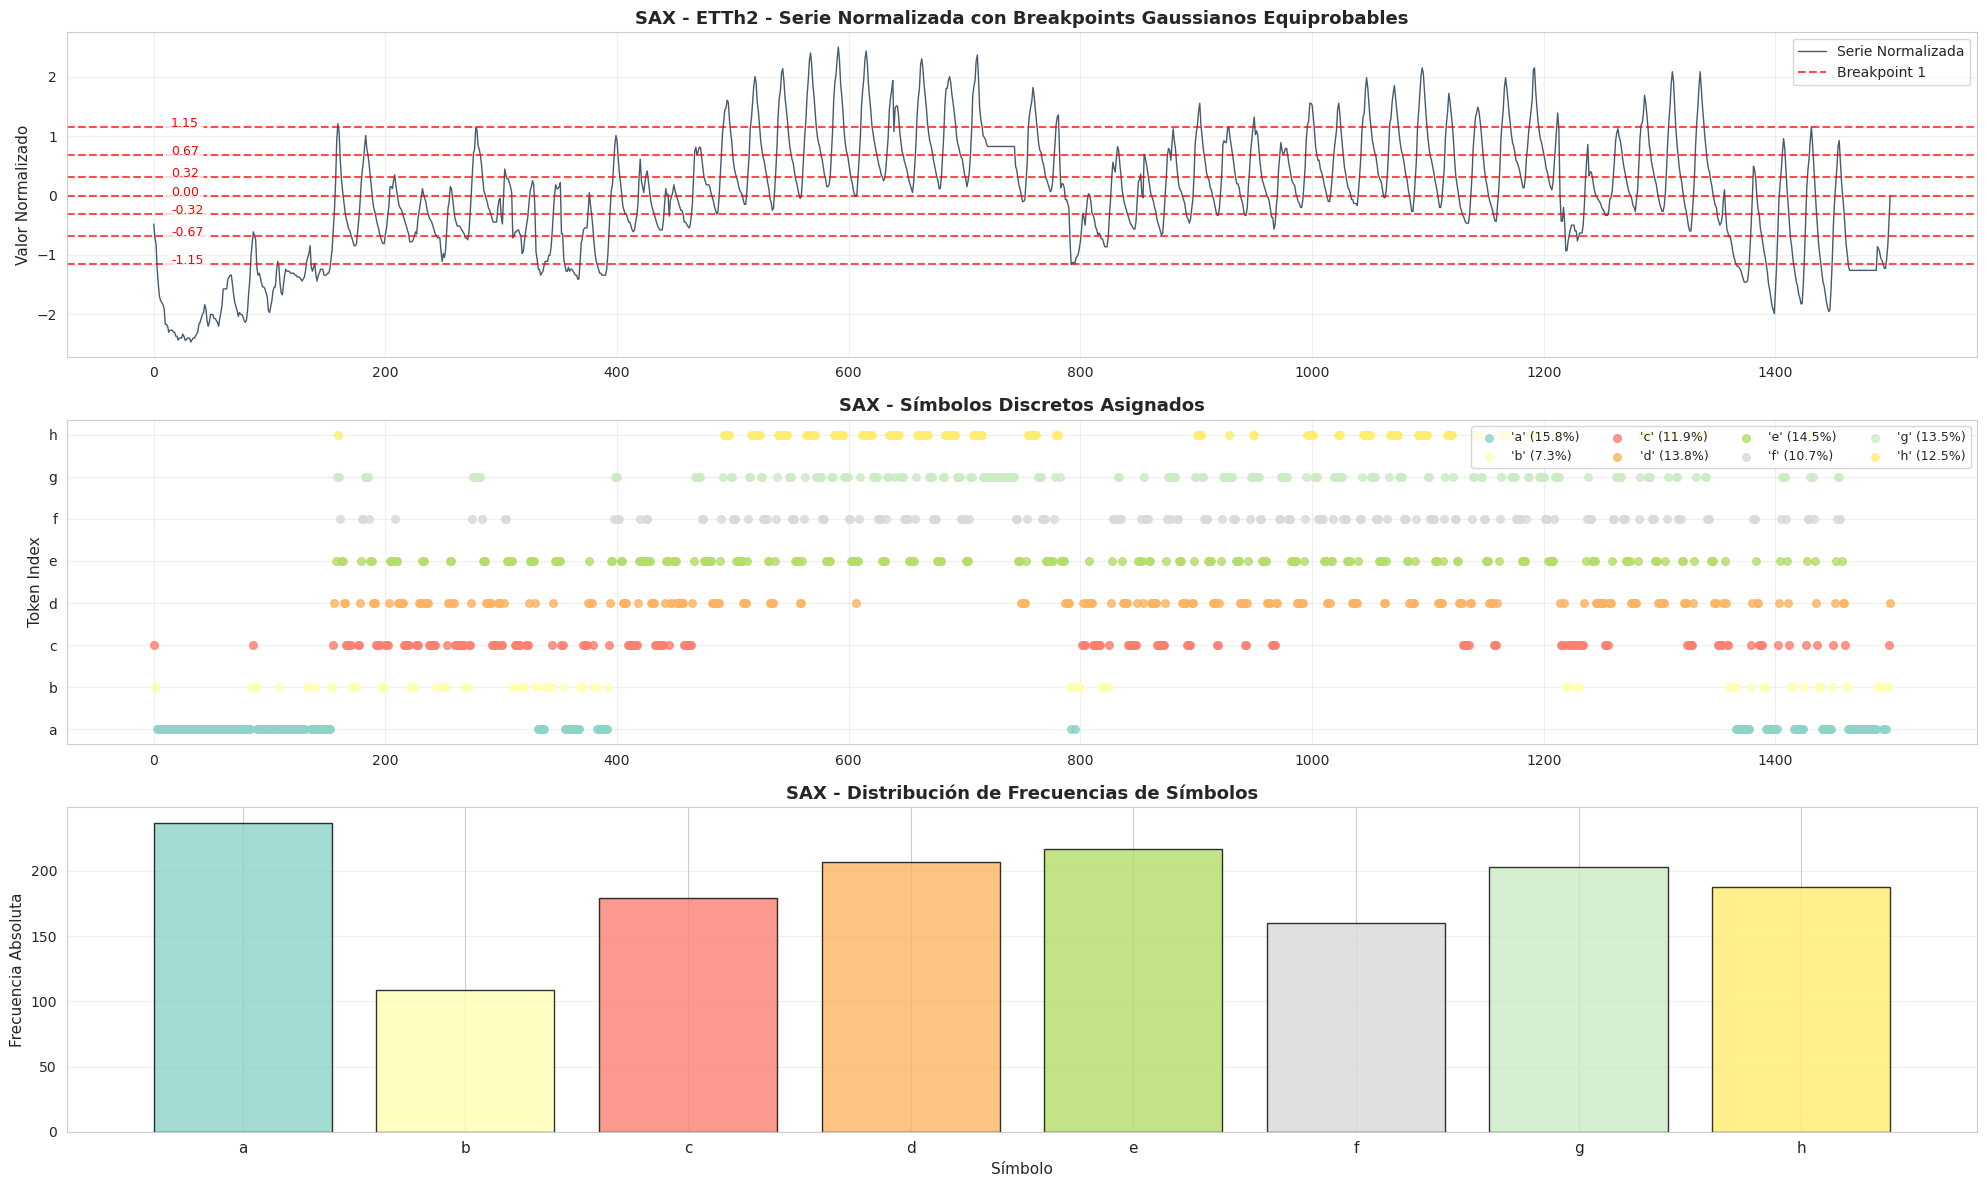

[ESTADÍSTICAS SAX - ETTh2]
  Vocabulary Size: 8
  Símbolos únicos usados: 8
  Num Tokens: 1500
  Compression Ratio: 1.0000 (sin compresión)

  Distribución de símbolos:
    'a': 237 (15.80%)
    'b': 109 (7.27%)
    'c': 179 (11.93%)
    'd': 207 (13.80%)
    'e': 217 (14.47%)
    'f': 160 (10.67%)
    'g': 203 (13.53%)
    'h': 188 (12.53%)


In [21]:
sax_viz = visualize_sax(etth2_series, etth2_sax['symbols'], etth2_sax['tokens'], etth2_sax['breakpoints'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 12))

ax1.plot(sax_viz['normalized'], linewidth=1, color='#34495E', alpha=0.9, label='Serie Normalizada')
for i, bp in enumerate(etth2_sax['breakpoints']):
    ax1.axhline(bp, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
                label=f'Breakpoint {i+1}' if i == 0 else '')
    ax1.text(len(etth2_series)*0.01, bp, f'{bp:.2f}', fontsize=9, color='red', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_title('SAX - ETTh2 - Serie Normalizada con Breakpoints Gaussianos Equiprobables', fontsize=13, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

colors_sax = plt.cm.Set3(np.linspace(0, 1, etth2_sax['vocabulary_size']))
for sym_idx in range(etth2_sax['vocabulary_size']):
    mask = etth2_sax['tokens'] == sym_idx
    if mask.any():
        count = mask.sum()
        pct = count / len(etth2_series) * 100
        ax2.scatter(np.where(mask)[0], etth2_sax['tokens'][mask], 
                   color=colors_sax[sym_idx], s=30, alpha=0.8, 
                   label=f"'{etth2_sax['alphabet'][sym_idx]}' ({pct:.1f}%)")

ax2.set_title('SAX - Símbolos Discretos Asignados', fontsize=13, fontweight='bold')
ax2.set_ylabel('Token Index', fontsize=11)
ax2.set_yticks(range(etth2_sax['vocabulary_size']))
ax2.set_yticklabels([etth2_sax['alphabet'][i] for i in range(etth2_sax['vocabulary_size'])])
ax2.legend(loc='upper right', ncol=4, fontsize=9)
ax2.grid(True, alpha=0.3)

unique, counts = np.unique(etth2_sax['symbols'], return_counts=True)
ax3.bar(range(len(unique)), counts, color=[colors_sax[etth2_sax['alphabet'].index(s)] for s in unique], 
        alpha=0.8, edgecolor='black', linewidth=1)
ax3.set_xlabel('Símbolo', fontsize=11)
ax3.set_ylabel('Frecuencia Absoluta', fontsize=11)
ax3.set_title('SAX - Distribución de Frecuencias de Símbolos', fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(unique)))
ax3.set_xticklabels(unique, fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS SAX - ETTh2]")
print(f"  Vocabulary Size: {etth2_sax['vocabulary_size']}")
print(f"  Símbolos únicos usados: {len(np.unique(etth2_sax['symbols']))}")
print(f"  Num Tokens: {etth2_sax['num_tokens']}")
print(f"  Compression Ratio: {etth2_sax['compression_ratio']:.4f} (sin compresión)")
print(f"\n  Distribución de símbolos:")
for sym, count in zip(unique, counts):
    pct = count / len(etth2_series) * 100
    print(f"    '{sym}': {count} ({pct:.2f}%)")

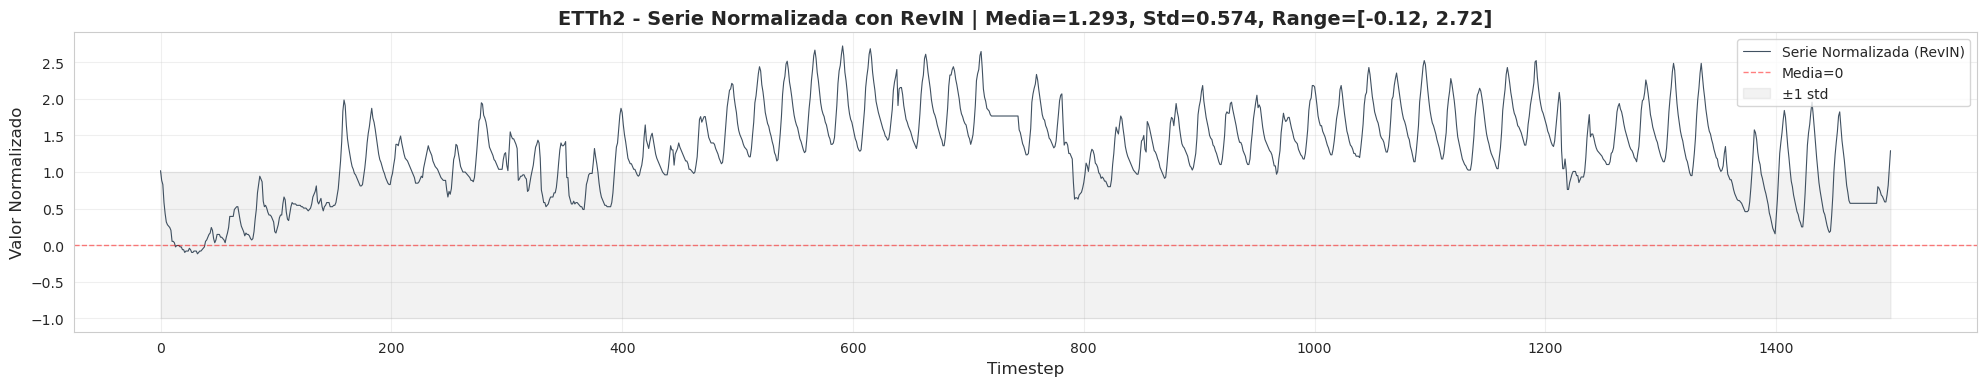

[ESTADÍSTICAS SERIE NORMALIZADA]
  Media: 1.292824 (debe estar cerca de 0)
  Desviación estándar: 0.573500 (debe estar cerca de 1)
  Min: -0.120, Max: 2.725
  Rango: 2.845


In [22]:
# 7.1 Serie Original Normalizada
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(etth2_series, linewidth=0.8, color='#2C3E50', alpha=0.9, label='Serie Normalizada (RevIN)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Media=0')
ax.fill_between(range(len(etth2_series)), -1, 1, alpha=0.1, color='gray', label='±1 std')

mean_val = etth2_series.mean()
std_val = etth2_series.std()
min_val = etth2_series.min()
max_val = etth2_series.max()

ax.set_title(f'ETTh2 - Serie Normalizada con RevIN | Media={mean_val:.3f}, Std={std_val:.3f}, Range=[{min_val:.2f}, {max_val:.2f}]', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Valor Normalizado', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[ESTADÍSTICAS SERIE NORMALIZADA]")
print(f"  Media: {mean_val:.6f} (debe estar cerca de 0)")
print(f"  Desviación estándar: {std_val:.6f} (debe estar cerca de 1)")
print(f"  Min: {min_val:.3f}, Max: {max_val:.3f}")
print(f"  Rango: {max_val - min_val:.3f}")

## 7.1 Serie Original Normalizada - ETTh2

## 8. Resumen Final y Conclusiones

In [23]:
print("\n" + "="*120)
print("RESUMEN FINAL - COMPARACIÓN DE TÉCNICAS DE TOKENIZACIÓN")
print("="*120)
print(table_combined.to_string(index=False))
print("="*120)

print("\n[OBSERVACIONES CLAVE]")
print("  1. HMM: Vocabulary Size K=5 estados, genera segmentos mediante cambios de régimen")
print("  2. SAX: Vocabulary Size 8 símbolos, sin compresión (1:1), discretización interpretable")
print("  3. LLMTime: Vocabulary Size 13 caracteres, expansión de datos (CR < 1), permite uso de LLMs")
print("  4. PatchTST: Vocabulary continuo, compresión moderada (~16), reduce complejidad cuadrática")
print("  5. Autoformer: Vocabulary 2 componentes, máxima compresión (750)")
print("  6. MOMENT: Similar a PatchTST, enfoque en pre-training con masking")

print("\n[INTERPRETACIÓN HMM]")
print("  - Vocabulary Size = K = 5 estados ocultos (regímenes)")
print("  - Num Tokens (Segmentos) = número de cambios de estado en secuencia Viterbi")
print("  - Compression Ratio = serie_len / num_segmentos")
print("  - A MAYOR CR, MEJOR compresión (menos tokens necesarios)")

print("\n[OK] Comparación completada exitosamente")


RESUMEN FINAL - COMPARACIÓN DE TÉCNICAS DE TOKENIZACIÓN
      Técnica  Num Tokens (Segmentos)  Compression Ratio Vocabulary Size           Tipo                 Paper     Dataset  Serie Length
HMM (Viterbi)                     223           6.726457               5 Probabilístico    Tesis RITMO (2025) Electricity          1500
          SAX                    1500           1.000000               8       Discreto     Lin et al. (2007) Electricity          1500
      LLMTime                   15826           0.094781              13        Textual  Gruver et al. (2023) Electricity          1500
     PatchTST                      93          16.129032        Continuo   Segmentación     Nie et al. (2023) Electricity          1500
   Autoformer                       2         750.000000   2 componentes Descomposición      Wu et al. (2021) Electricity          1500
       MOMENT                      93          16.129032       28 masked   Pre-training Goswami et al. (2024) Electricity      